In [ ]:
import pandas as pd
import random
import numpy as np
from random import randint
import torch
from datasets import load_dataset

import matplotlib.pyplot as plt
import matplotlib as mpl
import glasbey
from matplotlib import ticker

import pickle
import time
import memory_profiler
from tqdm.notebook import tqdm

%load_ext memory_profiler

from pathlib import Path
import distro

%load_ext watermark

In [ ]:
# old one '1.8.1+cu111'
torch.__version__

'2.5.0+cu124'

In [ ]:
%load_ext autoreload
%autoreload 2

from text_embeddings_src.load_mteb_scores_utils import *

In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
variables_path = Path("../results/variables")
# variables_pubmed_path = Path("../pubmed-landscape/results/variables")
figures_path = Path("../results/figures/updated_dataset")
data_path = Path("../data")
berenslab_data_path = Path("/gpfs01/berens/data/data/pubmed_processed")

In [ ]:
# MANUAL FIX TO PATH ISSUE FROM VSCODE
import text_embeddings_src

nb_path = Path(text_embeddings_src.__path__[0]).parents[0] / Path("scripts")
assert nb_path.exists(), "The path does not exist"

variables_path = (nb_path / variables_path).resolve(strict=True)
figures_path = (nb_path / figures_path).resolve(strict=True)
data_path = (nb_path / data_path).resolve(strict=True)

In [ ]:
plt.style.use((nb_path / Path("matplotlib_style.txt")).resolve(strict=True))

# MTEB benchmark

## Table 1

In [ ]:
tasks = [
    "ArxivClusteringP2P",
    "BiorxivClusteringP2P",
    "MedrxivClusteringP2P",
    "RedditClusteringP2P",
    "StackExchangeClusteringP2P",
    "SciDocsRR",
    "MindSmallReranking",
    "SCIDOCS",
    "ArguAna",
    "STS15",
    "STS16",
    "STSBenchmark",
    ##classification
    "AmazonPolarityClassification",  # sentiment: binary positive or negative
    "Banking77Classification",
    "ImdbClassification",  # sentiment: binary positive or negative
    "MassiveIntentClassification",  # multi
    "MassiveScenarioClassification",  # multi
    "MTOPDomainClassification",  # multi
    "TweetSentimentExtractionClassification",  # sentiment: positive, neutral negative
]

In [ ]:
columns = [
    "MPNet",
    "SimCSE",
    "Dropout",
    "Crops",
    "SBERT",
    "BGE-base",
    "BGE-large",
]
results = pd.DataFrame(
    columns=columns,
    index=tasks,
)
results

,MPNet,SimCSE,Dropout,Crops,SBERT,BGE-base,BGE-large
ArxivClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BiorxivClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MedrxivClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RedditClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StackExchangeClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SciDocsRR,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MindSmallReranking,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCIDOCS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ArguAna,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STS15,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
model_names = [
    "MPNet",
    "SimCSE",
    "MPNet",
    "MPNet",
    "SBERT",
]
finetune_types = [
    "",
    "",
    "simcse",
    "crops",
    "",
]

for i, (model_name, finetune_type) in enumerate(
    zip(model_names, finetune_types)
):
    saving_path = (
        Path("embeddings_" + model_name.lower())
        / Path("updated_dataset")
        / Path("mteb_benchmark")
    )
    saving_dir_str = (
        f"results_{model_name.lower()}"
        if finetune_type == ""
        else f"results_{model_name.lower()}_{finetune_type}_finetuning"
    )
    root_directory = variables_path / saving_path / saving_dir_str
    mteb_scores_model = create_results_dict(load_mteb_results(root_directory))

    for task in tasks:
        results.loc[task, columns[i]] = mteb_scores_model[task] * 100

In [ ]:
results

,MPNet,SimCSE,Dropout,Crops,SBERT,BGE-base,BGE-large
ArxivClusteringP2P,27.796505,35.42412,33.302522,38.314482,48.122866,NaN,NaN
BiorxivClusteringP2P,23.16813,30.097098,31.056539,32.398121,39.317648,NaN,NaN
MedrxivClusteringP2P,22.468333,28.033919,29.299436,30.846324,35.588148,NaN,NaN
RedditClusteringP2P,37.379575,44.696548,49.505427,55.851579,56.596703,NaN,NaN
StackExchangeClusteringP2P,26.347092,28.807583,30.229238,31.285922,34.313099,NaN,NaN
SciDocsRR,56.057909,69.518745,64.626432,73.61147,88.65397,NaN,NaN
MindSmallReranking,27.467857,29.252644,28.406821,30.165456,30.969453,NaN,NaN
SCIDOCS,1.393,7.905,6.493,13.043,23.765,NaN,NaN
ArguAna,22.227,41.43,41.861,50.645,46.521,NaN,NaN
STS15,53.48952,82.289648,63.475389,72.479485,85.6628,NaN,NaN


In [ ]:
df_bge = pd.read_csv(data_path / "mteb_leaderboard_rebuttal_selection.csv")
df_bge

,Unnamed: 0,Model,AmazonCounterfactualClassification,AmazonPolarityClassification,AmazonReviewsClassification,ArguAna,ArxivClusteringP2P,ArxivClusteringS2S,AskUbuntuDupQuestions,BIOSSES,...,StackExchangeClusteringP2P,StackOverflowDupQuestions,SummEval,TRECCOVID,Touche2020,ToxicConversationsClassification,TweetSentimentExtractionClassification,TwentyNewsgroupsClustering,TwitterSemEval2015,TwitterURLCorpus
0,36,bge-large-en-v1.5,73.940299,92.416675,50.230,64.516,48.567078,43.194534,64.465559,84.653736,...,34.963987,55.946945,31.605804,74.696,24.806,66.484375,59.943407,51.265977,79.043266,85.600750
1,50,bge-base-en-v1.5,75.014925,93.386825,50.734,63.752,48.748845,42.807589,62.128471,86.937523,...,35.238599,54.611641,31.067835,78.029,25.701,67.036133,59.380306,50.754008,77.678725,85.645215


In [ ]:
for task in tasks:
    results.loc[task, "BGE-base"] = df_bge[task][
        df_bge.Model == "bge-base-en-v1.5"
    ].iloc[0]
    results.loc[task, "BGE-large"] = df_bge[task][
        df_bge.Model == "bge-large-en-v1.5"
    ].iloc[0]

In [ ]:
results.astype(float).round(1)

,MPNet,SimCSE,Dropout,Crops,SBERT,BGE-base,BGE-large
ArxivClusteringP2P,27.8,35.4,33.3,38.3,48.1,48.7,48.6
BiorxivClusteringP2P,23.2,30.1,31.1,32.4,39.3,39.4,39.7
MedrxivClusteringP2P,22.5,28.0,29.3,30.8,35.6,33.2,32.6
RedditClusteringP2P,37.4,44.7,49.5,55.9,56.6,62.7,64.7
StackExchangeClusteringP2P,26.3,28.8,30.2,31.3,34.3,35.2,35.0
SciDocsRR,56.1,69.5,64.6,73.6,88.7,87.5,87.6
MindSmallReranking,27.5,29.3,28.4,30.2,31.0,31.2,32.1
SCIDOCS,1.4,7.9,6.5,13.0,23.8,21.7,22.6
ArguAna,22.2,41.4,41.9,50.6,46.5,63.8,64.5
STS15,53.5,82.3,63.5,72.5,85.7,88.0,88.0


In [ ]:
print(
    results.astype(float)
    .round(1)
    .to_latex(index=True, float_format="{:.1f}".format)
)

\begin{tabular}{lrrrrrrr}
\toprule
 & MPNet & SimCSE & Dropout & Crops & SBERT & BGE-base & BGE-large \\
\midrule
ArxivClusteringP2P & 27.8 & 35.4 & 33.3 & 38.3 & 48.1 & 48.7 & 48.6 \\
BiorxivClusteringP2P & 23.2 & 30.1 & 31.1 & 32.4 & 39.3 & 39.4 & 39.7 \\
MedrxivClusteringP2P & 22.5 & 28.0 & 29.3 & 30.8 & 35.6 & 33.2 & 32.6 \\
RedditClusteringP2P & 37.4 & 44.7 & 49.5 & 55.9 & 56.6 & 62.7 & 64.7 \\
StackExchangeClusteringP2P & 26.3 & 28.8 & 30.2 & 31.3 & 34.3 & 35.2 & 35.0 \\
SciDocsRR & 56.1 & 69.5 & 64.6 & 73.6 & 88.7 & 87.5 & 87.6 \\
MindSmallReranking & 27.5 & 29.3 & 28.4 & 30.2 & 31.0 & 31.2 & 32.1 \\
SCIDOCS & 1.4 & 7.9 & 6.5 & 13.0 & 23.8 & 21.7 & 22.6 \\
ArguAna & 22.2 & 41.4 & 41.9 & 50.6 & 46.5 & 63.8 & 64.5 \\
STS15 & 53.5 & 82.3 & 63.5 & 72.5 & 85.7 & 88.0 & 88.0 \\
STS16 & 50.6 & 77.7 & 66.2 & 76.0 & 80.0 & 85.5 & 86.5 \\
STSBenchmark & 52.0 & 78.6 & 67.9 & 71.7 & 83.4 & 86.4 & 87.5 \\
AmazonPolarityClassification & 66.5 & 72.0 & 63.3 & 62.5 & 67.1 & 93.4 & 92.4 \\
Bankin

In [ ]:
results.Crops - results.Dropout

ArxivClusteringP2P                         5.01196
BiorxivClusteringP2P                      1.341582
MedrxivClusteringP2P                      1.546888
RedditClusteringP2P                       6.346152
StackExchangeClusteringP2P                1.056684
SciDocsRR                                 8.985038
MindSmallReranking                        1.758635
SCIDOCS                                       6.55
ArguAna                                      8.784
STS15                                     9.004096
STS16                                     9.752022
STSBenchmark                              3.762759
AmazonPolarityClassification              -0.88405
Banking77Classification                   4.438312
ImdbClassification                         -1.2944
MassiveIntentClassification               0.904506
MassiveScenarioClassification             3.110289
MTOPDomainClassification                   2.48518
TweetSentimentExtractionClassification   -1.941143
dtype: object

In [ ]:
results.SimCSE - results.Dropout

ArxivClusteringP2P                         2.121599
BiorxivClusteringP2P                      -0.959441
MedrxivClusteringP2P                      -1.265517
RedditClusteringP2P                        -4.80888
StackExchangeClusteringP2P                -1.421655
SciDocsRR                                  4.892313
MindSmallReranking                         0.845823
SCIDOCS                                       1.412
ArguAna                                      -0.431
STS15                                     18.814259
STS16                                     11.480375
STSBenchmark                              10.702208
AmazonPolarityClassification                 8.6947
Banking77Classification                   11.116883
ImdbClassification                           0.3012
MassiveIntentClassification                7.481506
MassiveScenarioClassification              3.883658
MTOPDomainClassification                   0.166439
TweetSentimentExtractionClassification     0.594228
dtype: objec

### Block averages

In [ ]:
clustering = (
    results.loc[
        [
            "ArxivClusteringP2P",
            "BiorxivClusteringP2P",
            "MedrxivClusteringP2P",
            "RedditClusteringP2P",
            "StackExchangeClusteringP2P",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
reranking = (
    results.loc[
        [
            "SciDocsRR",
            "MindSmallReranking",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
retrieval = (
    results.loc[
        [
            "SCIDOCS",
            "ArguAna",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
sts = (
    results.loc[
        [
            "STS15",
            "STS16",
            "STSBenchmark",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
classification = (
    results.loc[
        [
            "AmazonPolarityClassification",  # sentiment: binary positive or negative
            "Banking77Classification",
            "ImdbClassification",  # sentiment: binary positive or negative
            "MassiveIntentClassification",  # multi
            "MassiveScenarioClassification",  # multi
            "MTOPDomainClassification",  # multi
            "TweetSentimentExtractionClassification",  # sentiment: positive, neutral negative
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
df_blocks = pd.DataFrame(clustering, columns=["clustering"])
df_blocks["reranking"] = reranking
df_blocks["retrieval"] = retrieval
df_blocks["sts"] = sts
df_blocks["classification"] = classification
df_blocks = df_blocks.T
df_blocks

,MPNet,SimCSE,Dropout,Crops,SBERT,BGE-base,BGE-large
clustering,27.4,33.4,34.7,37.7,42.8,43.9,44.1
reranking,41.8,49.4,46.5,51.9,59.8,59.3,59.8
retrieval,11.8,24.7,24.2,31.8,35.1,42.7,43.6
sts,52.0,79.5,65.9,73.4,83.0,86.6,87.3
classification,61.6,67.9,63.3,64.3,73.2,81.8,82.7


In [ ]:
df_blocks.mean(axis=0).round(1)

MPNet        38.9
SimCSE       51.0
Dropout      46.9
Crops        51.8
SBERT        58.8
BGE-base     62.9
BGE-large    63.5
dtype: float64

In [ ]:
print(np.mean(df_blocks.Crops - df_blocks.MPNet))
df_blocks.Crops - df_blocks.MPNet

12.9


clustering        10.3
reranking         10.1
retrieval         20.0
sts               21.4
classification     2.7
dtype: float64

In [ ]:
print(np.mean(df_blocks.SBERT - df_blocks.Crops))
df_blocks.SBERT - df_blocks.Crops

6.959999999999999


clustering        5.1
reranking         7.9
retrieval         3.3
sts               9.6
classification    8.9
dtype: float64

In [ ]:
print(np.mean(df_blocks["BGE-base"] - df_blocks.SBERT))
df_blocks["BGE-base"] - df_blocks.SBERT

4.079999999999998


clustering        1.1
reranking        -0.5
retrieval         7.6
sts               3.6
classification    8.6
dtype: float64

In [ ]:
print(np.mean(df_blocks["BGE-large"] - df_blocks.SBERT))
df_blocks["BGE-large"] - df_blocks.SBERT

4.720000000000001


clustering        1.3
reranking         0.0
retrieval         8.5
sts               4.3
classification    9.5
dtype: float64

In [ ]:
print(
    np.mean(
        [
            np.mean(df_blocks["BGE-base"] - df_blocks.SBERT),
            np.mean(df_blocks["BGE-large"] - df_blocks.SBERT),
        ]
    )
)

4.3999999999999995


In [ ]:
print(
    np.mean(
        [
            np.mean(df_blocks["BGE-base"] - df_blocks.Crops),
            np.mean(df_blocks["BGE-large"] - df_blocks.Crops),
        ]
    )
)

11.359999999999998


## Table S1

In [ ]:
tasks = [
    "ArxivClusteringP2P",
    "BiorxivClusteringP2P",
    "MedrxivClusteringP2P",
    "RedditClusteringP2P",
    "StackExchangeClusteringP2P",
    "SciDocsRR",
    "MindSmallReranking",
    "SCIDOCS",
    "ArguAna",
    "STS15",
    "STS16",
    "STSBenchmark",
    ##classification
    "AmazonPolarityClassification",  # sentiment: binary positive or negative
    "Banking77Classification",
    "ImdbClassification",  # sentiment: binary positive or negative
    "MassiveIntentClassification",  # multi
    "MassiveScenarioClassification",  # multi
    "MTOPDomainClassification",  # multi
    "TweetSentimentExtractionClassification",  # sentiment: positive, neutral negative
]

In [ ]:
columns = [
    "MPNet",
    "MPNet Dropout",
    "MPNet Crops",
    "BERT",
    "BERT Dropout",
    "BERT Crops",
    "RoBERTa",
    "RoBERTa Dropout",
    "RoBERTa Crops",
]
results = pd.DataFrame(
    columns=columns,
    index=tasks,
)
results

,MPNet,MPNet Dropout,MPNet Crops,BERT,BERT Dropout,BERT Crops,RoBERTa,RoBERTa Dropout,RoBERTa Crops
ArxivClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BiorxivClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MedrxivClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RedditClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StackExchangeClusteringP2P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SciDocsRR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MindSmallReranking,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCIDOCS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ArguAna,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STS15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
model_names = [
    "MPNet",
    "MPNet",
    "MPNet",
    "BERT",
    "BERT",
    "BERT",
    "RoBERTa",
    "RoBERTa",
    "RoBERTa",
]
finetune_types = [
    "",
    "simcse",
    "crops",
    "",
    "simcse",
    "crops",
    "",
    "simcse",
    "crops",
]


for i, (model_name, finetune_type) in enumerate(
    zip(model_names, finetune_types)
):
    saving_path = (
        Path("embeddings_" + model_name.lower())
        / Path("updated_dataset")
        / Path("mteb_benchmark")
    )
    saving_dir_str = (
        f"results_{model_name.lower()}"
        if finetune_type == ""
        else f"results_{model_name.lower()}_{finetune_type}_finetuning"
    )
    root_directory = variables_path / saving_path / saving_dir_str
    mteb_scores_model = create_results_dict(load_mteb_results(root_directory))

    for task in tasks:
        results.loc[task, columns[i]] = mteb_scores_model[task] * 100

In [ ]:
results.astype(float).round(1)

,MPNet,MPNet Dropout,MPNet Crops,BERT,BERT Dropout,BERT Crops,RoBERTa,RoBERTa Dropout,RoBERTa Crops
ArxivClusteringP2P,27.8,33.3,38.3,35.3,37.8,38.7,23.1,34.1,37.0
BiorxivClusteringP2P,23.2,31.1,32.4,29.9,31.7,31.8,16.2,31.4,32.7
MedrxivClusteringP2P,22.5,29.3,30.8,26.1,28.6,29.7,19.5,29.9,30.3
RedditClusteringP2P,37.4,49.5,55.9,43.5,48.2,51.9,26.0,50.9,53.5
StackExchangeClusteringP2P,26.3,30.2,31.3,26.5,29.1,30.0,24.8,30.7,30.7
SciDocsRR,56.1,64.6,73.6,64.9,65.4,73.5,52.7,63.7,69.2
MindSmallReranking,27.5,28.4,30.2,28.4,29.4,29.5,27.9,30.5,28.4
SCIDOCS,1.4,6.5,13.0,2.8,4.5,11.1,0.4,3.8,5.2
ArguAna,22.2,41.9,50.6,28.3,38.1,47.8,14.0,44.2,44.9
STS15,53.5,63.5,72.5,60.3,58.1,70.5,61.3,69.5,67.1


In [ ]:
results["BERT Crops"] - results["BERT Dropout"]

ArxivClusteringP2P                         0.971639
BiorxivClusteringP2P                       0.113689
MedrxivClusteringP2P                       1.146953
RedditClusteringP2P                        3.713018
StackExchangeClusteringP2P                 0.925173
SciDocsRR                                  8.156017
MindSmallReranking                         0.146386
SCIDOCS                                       6.604
ArguAna                                       9.684
STS15                                      12.38215
STS16                                      7.097377
STSBenchmark                              10.889904
AmazonPolarityClassification              -4.260675
Banking77Classification                    9.581169
ImdbClassification                          -3.0912
MassiveIntentClassification                 3.62811
MassiveScenarioClassification              4.522529
MTOPDomainClassification                   3.153215
TweetSentimentExtractionClassification    -2.382569
dtype: objec

In [ ]:
results["RoBERTa Crops"] - results["RoBERTa Dropout"]

ArxivClusteringP2P                        2.889465
BiorxivClusteringP2P                      1.316984
MedrxivClusteringP2P                      0.349162
RedditClusteringP2P                       2.688513
StackExchangeClusteringP2P               -0.088351
SciDocsRR                                 5.534314
MindSmallReranking                       -2.161936
SCIDOCS                                      1.485
ArguAna                                      0.646
STS15                                    -2.400123
STS16                                     2.886535
STSBenchmark                              0.688677
AmazonPolarityClassification              0.075275
Banking77Classification                   3.970779
ImdbClassification                         -2.6916
MassiveIntentClassification               1.133154
MassiveScenarioClassification             0.279085
MTOPDomainClassification                  4.008208
TweetSentimentExtractionClassification     1.47708
dtype: object

### Block averages

In [ ]:
clustering = (
    results.loc[
        [
            "ArxivClusteringP2P",
            "BiorxivClusteringP2P",
            "MedrxivClusteringP2P",
            "RedditClusteringP2P",
            "StackExchangeClusteringP2P",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
reranking = (
    results.loc[
        [
            "SciDocsRR",
            "MindSmallReranking",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
retrieval = (
    results.loc[
        [
            "SCIDOCS",
            "ArguAna",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
sts = (
    results.loc[
        [
            "STS15",
            "STS16",
            "STSBenchmark",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
classification = (
    results.loc[
        [
            "AmazonPolarityClassification",  # sentiment: binary positive or negative
            "Banking77Classification",
            "ImdbClassification",  # sentiment: binary positive or negative
            "MassiveIntentClassification",  # multi
            "MassiveScenarioClassification",  # multi
            "MTOPDomainClassification",  # multi
            "TweetSentimentExtractionClassification",  # sentiment: positive, neutral negative
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
df_blocks = pd.DataFrame(clustering, columns=["clustering"])
df_blocks["reranking"] = reranking
df_blocks["retrieval"] = retrieval
df_blocks["sts"] = sts
df_blocks["classification"] = classification
df_blocks = df_blocks.T
df_blocks

,MPNet,MPNet Dropout,MPNet Crops,BERT,BERT Dropout,BERT Crops,RoBERTa,RoBERTa Dropout,RoBERTa Crops
clustering,27.4,34.7,37.7,32.3,35.1,36.4,21.9,35.4,36.8
reranking,41.8,46.5,51.9,46.7,47.4,51.5,40.3,47.1,48.8
retrieval,11.8,24.2,31.8,15.6,21.3,29.4,7.2,24.0,25.0
sts,52.0,65.9,73.4,57.1,59.4,69.6,59.3,69.8,70.2
classification,61.6,63.3,64.3,65.5,62.6,64.2,63.3,63.5,64.7


In [ ]:
print(df_blocks.to_latex(index=True, float_format="{:.1f}".format))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & MPNet & MPNet Dropout & MPNet Crops & BERT & BERT Dropout & BERT Crops & RoBERTa & RoBERTa Dropout & RoBERTa Crops \\
\midrule
clustering & 27.4 & 34.7 & 37.7 & 32.3 & 35.1 & 36.4 & 21.9 & 35.4 & 36.8 \\
reranking & 41.8 & 46.5 & 51.9 & 46.7 & 47.4 & 51.5 & 40.3 & 47.1 & 48.8 \\
retrieval & 11.8 & 24.2 & 31.8 & 15.6 & 21.3 & 29.4 & 7.2 & 24.0 & 25.0 \\
sts & 52.0 & 65.9 & 73.4 & 57.1 & 59.4 & 69.6 & 59.3 & 69.8 & 70.2 \\
classification & 61.6 & 63.3 & 64.3 & 65.5 & 62.6 & 64.2 & 63.3 & 63.5 & 64.7 \\
\bottomrule
\end{tabular}



In [ ]:
df_blocks.mean(axis=0).round(1)

MPNet              38.9
MPNet Dropout      46.9
MPNet Crops        51.8
BERT               43.4
BERT Dropout       45.2
BERT Crops         50.2
RoBERTa            38.4
RoBERTa Dropout    48.0
RoBERTa Crops      49.1
dtype: float64

In [ ]:
print(np.mean(df_blocks["BERT Crops"] - df_blocks["BERT"]))
df_blocks["BERT Crops"] - df_blocks["BERT"]

6.7799999999999985


clustering         4.1
reranking          4.8
retrieval         13.8
sts               12.5
classification    -1.3
dtype: float64

In [ ]:
print(np.mean(df_blocks["RoBERTa Crops"] - df_blocks["RoBERTa"]))
df_blocks["RoBERTa Crops"] - df_blocks["RoBERTa"]

10.700000000000003


clustering        14.9
reranking          8.5
retrieval         17.8
sts               10.9
classification     1.4
dtype: float64

## RandomBERT, Embdd numbers

In [ ]:
tasks = [
    "ArxivClusteringP2P",
    "BiorxivClusteringP2P",
    "MedrxivClusteringP2P",
    "RedditClusteringP2P",
    "StackExchangeClusteringP2P",
    "SciDocsRR",
    "MindSmallReranking",
    "SCIDOCS",
    "ArguAna",
    "STS15",
    "STS16",
    "STSBenchmark",
    # ##classification
    # "AmazonPolarityClassification",  # sentiment: binary positive or negative
    # "Banking77Classification",
    # "ImdbClassification",  # sentiment: binary positive or negative
    # "MassiveIntentClassification",  # multi
    # "MassiveScenarioClassification",  # multi
    # "MTOPDomainClassification",  # multi
    # "TweetSentimentExtractionClassification",  # sentiment: positive, neutral negative
]

In [ ]:
columns = ["Embd10", "RandomBERT10"]
results = pd.DataFrame(
    columns=columns,
    index=tasks,
)
results

,Embd10,RandomBERT10
ArxivClusteringP2P,NaN,NaN
BiorxivClusteringP2P,NaN,NaN
MedrxivClusteringP2P,NaN,NaN
RedditClusteringP2P,NaN,NaN
StackExchangeClusteringP2P,NaN,NaN
SciDocsRR,NaN,NaN
MindSmallReranking,NaN,NaN
SCIDOCS,NaN,NaN
ArguAna,NaN,NaN
STS15,NaN,NaN


In [ ]:
# embedding layer
saving_path = (
    Path("embeddings_random_bert")
    / Path("updated_dataset")
    / Path("mteb_benchmark")
)
root_directory = (
    variables_path / saving_path / "results_embedding_layer_random_bert"
)
mteb_scores_model = create_results_dict(load_mteb_results(root_directory))

for task in tasks:
    results.loc[task, "Embd10"] = mteb_scores_model[task] * 100


# random bert (10 epochs)
model_name = "random_bert"
saving_path = (
    Path("embeddings_random_bert")
    / Path("updated_dataset")
    / Path("mteb_benchmark")
)
root_directory = (
    variables_path
    / saving_path
    / f"results_{model_name.lower()}_crops_finetuning_10_epochs"
)
mteb_scores_model = create_results_dict(load_mteb_results(root_directory))
for task in tasks:
    results.loc[task, "RandomBERT10"] = mteb_scores_model[task] * 100

In [ ]:
results.astype(float).round(1)

,Embd10,RandomBERT10
ArxivClusteringP2P,24.2,19.0
BiorxivClusteringP2P,19.2,10.6
MedrxivClusteringP2P,20.2,16.7
RedditClusteringP2P,20.7,16.5
StackExchangeClusteringP2P,26.3,23.0
SciDocsRR,65.6,55.5
MindSmallReranking,25.9,23.3
SCIDOCS,9.6,2.1
ArguAna,24.1,9.5
STS15,63.8,62.8


### Block averages

In [ ]:
clustering = (
    results.loc[
        [
            "ArxivClusteringP2P",
            "BiorxivClusteringP2P",
            "MedrxivClusteringP2P",
            "RedditClusteringP2P",
            "StackExchangeClusteringP2P",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
reranking = (
    results.loc[
        [
            "SciDocsRR",
            "MindSmallReranking",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
retrieval = (
    results.loc[
        [
            "SCIDOCS",
            "ArguAna",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
sts = (
    results.loc[
        [
            "STS15",
            "STS16",
            "STSBenchmark",
        ]
    ]
    .mean(axis=0)
    .astype(float)
    .round(1)
)

In [ ]:
df_blocks = pd.DataFrame(clustering, columns=["clustering"])
df_blocks["reranking"] = reranking
df_blocks["retrieval"] = retrieval
df_blocks["sts"] = sts
df_blocks = df_blocks.T
df_blocks

,Embd10,RandomBERT10
clustering,22.1,17.2
reranking,45.8,39.4
retrieval,16.8,5.8
sts,56.5,56.8


In [ ]:
df_blocks.loc["clustering", "Crops"] = 37.7
df_blocks.loc["reranking", "Crops"] = 51.9
df_blocks.loc["retrieval", "Crops"] = 31.8
df_blocks.loc["sts", "Crops"] = 73.4
df_blocks

,Embd10,RandomBERT10,Crops
clustering,22.1,17.2,37.7
reranking,45.8,39.4,51.9
retrieval,16.8,5.8,31.8
sts,56.5,56.8,73.4


In [ ]:
df_blocks.mean(axis=0).round(1)

Embd10          35.3
RandomBERT10    29.8
Crops           48.7
dtype: float64

In [ ]:
print(np.mean(df_blocks.Crops - df_blocks.RandomBERT10))
df_blocks.Crops - df_blocks.RandomBERT10

18.900000000000002


clustering    20.5
reranking     12.5
retrieval     26.0
sts           16.6
dtype: float64

In [ ]:
print(np.mean(df_blocks.Crops - df_blocks.Embd10))
df_blocks.Crops - df_blocks.Embd10

13.400000000000002


clustering    15.6
reranking      6.1
retrieval     15.0
sts           16.9
dtype: float64

# MTEB datasets for kNN evaluation

## Stats

In [ ]:
datasets_names = [
    # "arxiv",
    "biorxiv",
    "medrxiv",
    "reddit",
    "stackexchange",
]
datasets_paths = [
    # "mteb/arxiv-clustering-p2p",
    "mteb/biorxiv-clustering-p2p",
    "mteb/medrxiv-clustering-p2p",
    "mteb/reddit-clustering-p2p",
    "mteb/stackexchange-clustering-p2p",
]

In [ ]:
dataset_stats = pd.DataFrame(
    columns=[
        "# samples",
        "# classes",
        "Mean length",
        "Std length",
    ],
    index=datasets_names,
)
dataset_stats

,# samples,# classes,Mean length,Std length
biorxiv,NaN,NaN,NaN,NaN
medrxiv,NaN,NaN,NaN,NaN
reddit,NaN,NaN,NaN,NaN
stackexchange,NaN,NaN,NaN,NaN


In [ ]:
for i, dataset_name in enumerate(datasets_names):
    print(dataset_name)
    dataset = load_dataset(datasets_paths[i])
    sentences = list(
        np.hstack(dataset.data["test"].to_pandas().sentences.to_numpy())
    )
    labels = list(
        np.hstack(dataset.data["test"].to_pandas().labels.to_numpy())
    )

    # calculate stats
    dataset_stats["# samples"].loc[dataset_name] = len(labels)
    dataset_stats["# classes"].loc[dataset_name] = len(np.unique(labels))

    length = [len(x) for x in sentences]
    dataset_stats["Mean length"].loc[dataset_name] = int(
        np.round(np.mean(length))
    )
    dataset_stats["Std length"].loc[dataset_name] = int(
        np.round(np.std(length))
    )

biorxiv
medrxiv
reddit
stackexchange


In [ ]:
dataset_stats

,# samples,# classes,Mean length,Std length
biorxiv,53787,26,1664,542
medrxiv,17647,51,1985,843
reddit,459399,450,728,710
stackexchange,75000,610,1091,809


#### Add ICLR

In [ ]:
%%time
iclr2024 = pd.read_parquet(
    data_path / "iclr2024.parquet.gzip",
    # index=False,
    engine="pyarrow",
    # compression="gzip",
)

CPU times: user 321 ms, sys: 77.1 ms, total: 398 ms
Wall time: 732 ms


In [ ]:
iclr2024.head()

,index,year,id,title,abstract,authors,decision,scores,keywords,gender-first,gender-last,t-SNE x,t-SNE y
0,0,2017,S1VaB4cex,FractalNet: Ultra-Deep Neural Networks without...,We introduce a design strategy for neural netw...,"Gustav Larsson, Michael Maire, Gregory Shakhna...",Accept (Poster),"[5, 7, 6, 6]",[],male,male,-28.117955,-20.418127
1,1,2017,H1W1UN9gg,Deep Information Propagation,We study the behavior of untrained neural netw...,"Samuel S. Schoenholz, Justin Gilmer, Surya Gan...",Accept (Poster),"[8, 9, 8]","[theory, deep learning]",male,None,-32.466820,-10.791123
2,2,2017,r1GKzP5xx,Recurrent Normalization Propagation,We propose a LSTM parametrization that preser...,"César Laurent, Nicolas Ballas, Pascal Vincent",Invite to Workshop Track,"[4, 6, 6]","[deep learning, optimization]",None,male,3.504240,19.946053
3,3,2017,S1J0E-71l,Surprisal-Driven Feedback in Recurrent Networks,Recurrent neural nets are widely used for pred...,"K, a, m, i, l, , R, o, c, k, i",Reject,"[3, 4, 3]","[unsupervised learning, applications, deep lea...",None,None,4.553473,16.037763
4,4,2017,SJGCiw5gl,Pruning Convolutional Neural Networks for Reso...,We propose a new formulation for pruning convo...,"Pavlo Molchanov, Stephen Tyree, Tero Karras, T...",Accept (Poster),"[6, 7, 9]","[deep learning, transfer learning]",None,male,-25.827705,-37.891772


In [ ]:
labels_iclr = np.load(variables_path / "updated_dataset" / "labels_iclr.npy")

In [ ]:
# calculate stats
dataset_stats.loc["ICLR"] = np.zeros(len(dataset_stats.iloc[0]))

dataset_stats["# samples"].loc["ICLR"] = len(labels_iclr)
dataset_stats["# classes"].loc["ICLR"] = len(np.unique(labels_iclr))
length = [len(x) for x in iclr2024.abstract.to_numpy()]
dataset_stats["Mean length"].loc["ICLR"] = int(np.round(np.mean(length)))
dataset_stats["Std length"].loc["ICLR"] = int(np.round(np.std(length)))

In [ ]:
dataset_stats

,# samples,# classes,Mean length,Std length
biorxiv,53787,26,1664,542
medrxiv,17647,51,1985,843
reddit,459399,450,728,710
stackexchange,75000,610,1091,809
ICLR,24347,46,1248,316


### Add arxiv

In [ ]:
dataset_name = "arxiv"
dataset_path = "mteb/arxiv-clustering-p2p"

In [ ]:
dataset = load_dataset("mteb/arxiv-clustering-p2p")

In [ ]:
sentences = list(
    np.hstack(dataset.data["test"].to_pandas().sentences.to_numpy())
)
labels_secondary = list(
    np.hstack(dataset.data["test"].to_pandas().labels.to_numpy())
)

In [ ]:
labels_main = [elem.split(".")[0] for elem in labels_secondary]

In [ ]:
# calculate stats
dataset_stats.loc["arxiv_main"] = np.zeros(len(dataset_stats.iloc[0]))

dataset_stats["# samples"].loc["arxiv_main"] = len(labels_main)
dataset_stats["# classes"].loc["arxiv_main"] = len(np.unique(labels_main))
length = [len(x) for x in sentences]
dataset_stats["Mean length"].loc["arxiv_main"] = int(np.round(np.mean(length)))
dataset_stats["Std length"].loc["arxiv_main"] = int(np.round(np.std(length)))

In [ ]:
# calculate stats
dataset_stats.loc["arxiv_secondary"] = np.zeros(len(dataset_stats.iloc[0]))

dataset_stats["# samples"].loc["arxiv_secondary"] = len(labels_secondary)
dataset_stats["# classes"].loc["arxiv_secondary"] = len(
    np.unique(labels_secondary)
)
length = [len(x) for x in sentences]
dataset_stats["Mean length"].loc["arxiv_secondary"] = int(
    np.round(np.mean(length))
)
dataset_stats["Std length"].loc["arxiv_secondary"] = int(
    np.round(np.std(length))
)

In [ ]:
dataset_stats

,# samples,# classes,Mean length,Std length
biorxiv,53787,26,1664,542
medrxiv,17647,51,1985,843
reddit,459399,450,728,710
stackexchange,75000,610,1091,809
ICLR,24347,46,1248,316
arxiv_main,732723,39,1010,432
arxiv_secondary,732723,180,1010,432


In [ ]:
print(dataset_stats)

                # samples # classes Mean length Std length
biorxiv             53787        26        1664        542
medrxiv             17647        51        1985        843
reddit             459399       450         728        710
stackexchange       75000       610        1091        809
ICLR                24347        46        1248        316
arxiv_main         732723        39        1010        432
arxiv_secondary    732723       180        1010        432


### Biorxiv

In [ ]:
dataset_name = "biorxiv"
dataset_path = "mteb/biorxiv-clustering-p2p"

In [ ]:
dataset = load_dataset(dataset_path)

In [ ]:
dataset

DatasetDict({
    test: Dataset({
        features: ['sentences', 'labels'],
        num_rows: 53787
    })
})

In [ ]:
sentences = list(
    np.hstack(dataset.data["test"].to_pandas().sentences.to_numpy())
)
labels = list(np.hstack(dataset.data["test"].to_pandas().labels.to_numpy()))

In [ ]:
print("# samples", len(labels))
print("# classes", len(np.unique(labels)))

# samples 53787
# classes 26


In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)

In [ ]:
colors = np.load(
    variables_path / "updated_dataset" / f"colors_{dataset_name}.npy"
)
pickle_in = open(
    variables_path
    / "updated_dataset"
    / f"dict_label_to_color_{dataset_name}.pkl",
    "rb",
)
dict_label_to_color = pickle.load(pickle_in)

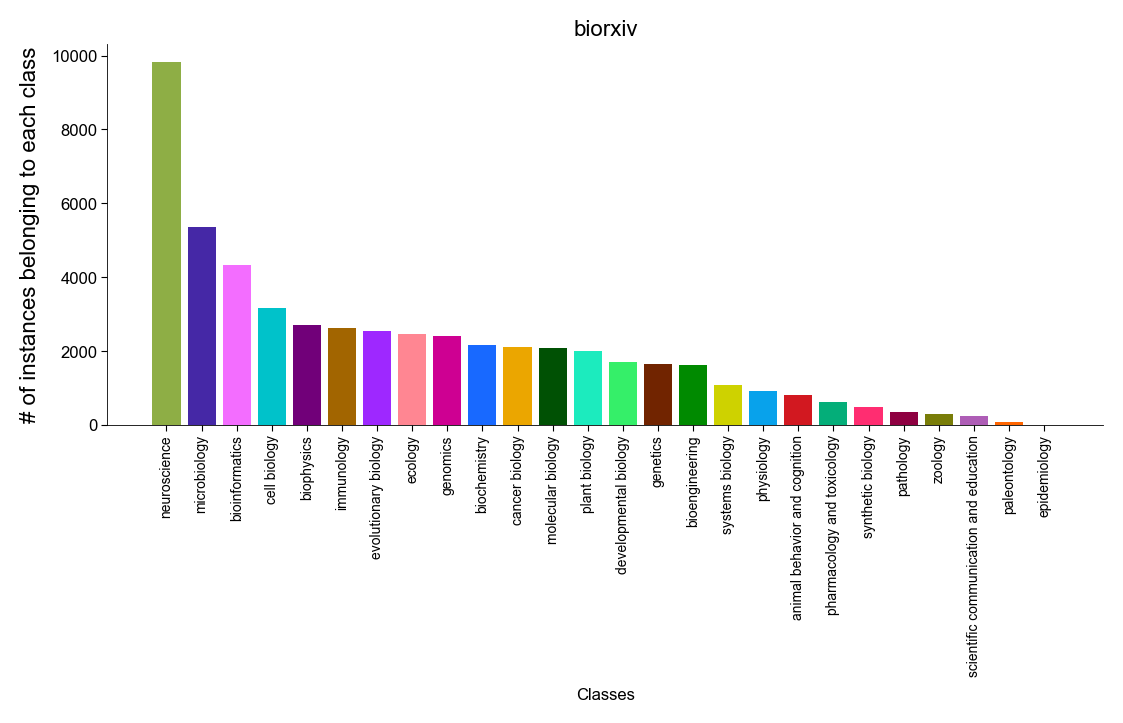

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=200, layout="constrained")

ax.bar(
    np.arange(len(np.unique(labels))),
    np.flip(np.sort(counts)),
    color=np.array(list(dict_label_to_color.values()))[
        np.flip(np.argsort(counts))
    ],
)

ax.set_xticks(
    np.arange(len(np.unique(labels))),
    labels=unique_labels[np.flip(np.argsort(counts))],
    rotation="vertical",
    fontsize=5,
)
ax.set_ylabel("# of instances belonging to each class", fontsize=8)
ax.set_xlabel("Classes")
ax.set_title(f"{dataset_name}")


fig.savefig(figures_path / f"barplot_class_distribution_{dataset_name}.png")

### Medrxiv

In [ ]:
dataset_name = "medrxiv"
dataset_path = "mteb/medrxiv-clustering-p2p"

In [ ]:
dataset = load_dataset(dataset_path)

In [ ]:
dataset

DatasetDict({
    test: Dataset({
        features: ['sentences', 'labels'],
        num_rows: 17647
    })
})

In [ ]:
sentences = list(
    np.hstack(dataset.data["test"].to_pandas().sentences.to_numpy())
)
labels = list(np.hstack(dataset.data["test"].to_pandas().labels.to_numpy()))

In [ ]:
print("# samples", len(labels))
print("# classes", len(np.unique(labels)))

# samples 17647
# classes 51


In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)

In [ ]:
colors = np.load(
    variables_path / "updated_dataset" / f"colors_{dataset_name}.npy"
)
pickle_in = open(
    variables_path
    / "updated_dataset"
    / f"dict_label_to_color_{dataset_name}.pkl",
    "rb",
)
dict_label_to_color = pickle.load(pickle_in)

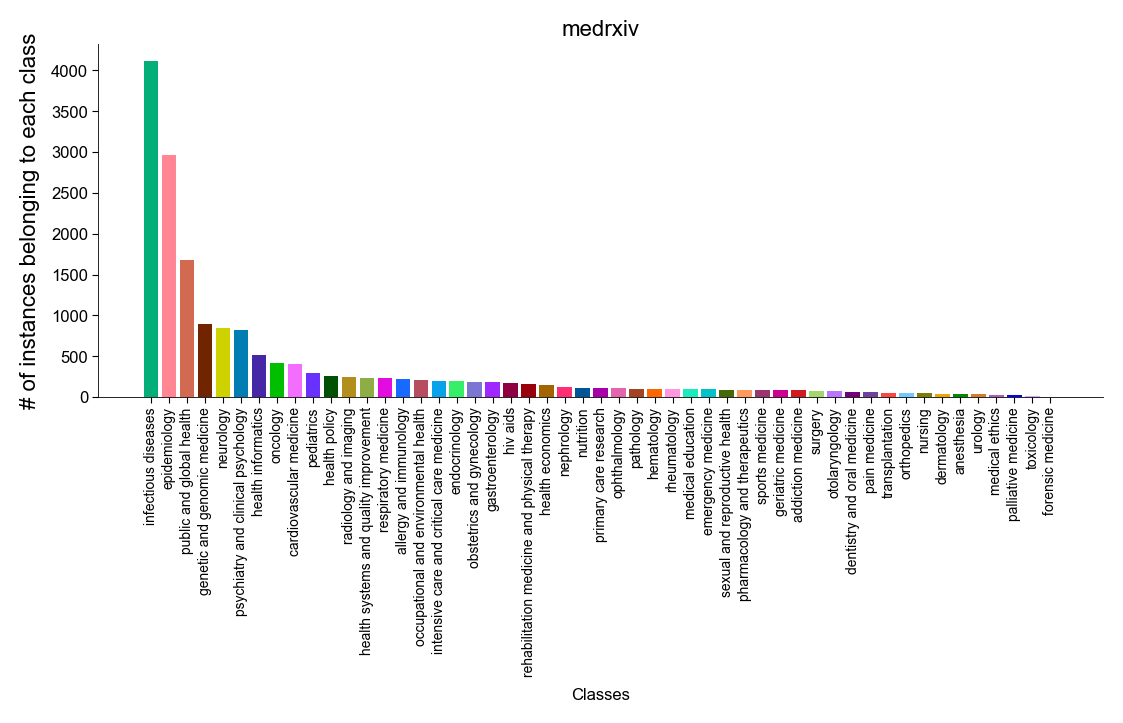

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=200, layout="constrained")

ax.bar(
    np.arange(len(np.unique(labels))),
    np.flip(np.sort(counts)),
    color=np.array(list(dict_label_to_color.values()))[
        np.flip(np.argsort(counts))
    ],
)

ax.set_xticks(
    np.arange(len(np.unique(labels))),
    labels=unique_labels[np.flip(np.argsort(counts))],
    rotation="vertical",
    fontsize=5,
)
ax.set_ylabel("# of instances belonging to each class", fontsize=8)
ax.set_xlabel("Classes")
ax.set_title(f"{dataset_name}")


fig.savefig(figures_path / f"barplot_class_distribution_{dataset_name}.png")

### Reddit

In [ ]:
from datasets import load_dataset

dataset_reddit = load_dataset("mteb/reddit-clustering-p2p")
# dataset_reddit = load_dataset("mteb/stackexchange-clustering-p2p")

In [ ]:
reddit_sentences = np.hstack(
    dataset_reddit.data["test"].to_pandas().sentences.to_numpy()
)

In [ ]:
len(reddit_sentences)

459399

In [ ]:
reddit_labels = np.hstack(
    dataset_reddit.data["test"].to_pandas().labels.to_numpy()
)

In [ ]:
len(reddit_labels)

459399

In [ ]:
unique_labels, counts = np.unique(reddit_labels, return_counts=True)

In [ ]:
unique_labels

array(['1200isplentyketo', '196', '40kLore', '90dayfianceuncensored',
       'ABA', 'ABraThatFits', 'ACTrade', 'ADHD', 'Adopted', 'Aerials',
       'AgonGame', 'AirForce', 'AirReps', 'Aliexpress', 'AmItheAsshole',
       'AmazonFC', 'AmongUs', 'ApplyingToCollege', 'AskAnAmerican',
       'AskCulinary', 'AskGames', 'AskGirls', 'AskLosAngeles', 'AskVet',
       'AssassinsCreedValhala', 'AstroGaming', 'BDSMcommunity', 'BMW',
       'BangaloreMains', 'Bariloche', 'Bath', 'Baystreetbets',
       'BenignExistence', 'Bestbuy', 'Bible', 'BitLifeApp',
       'BlackCountryNewRoad', 'Bogleheads', 'BokunoheroFanfiction',
       'BreakUps', 'BroadCity', 'BuddyCrossing', 'C25K',
       'COVID19positive', 'CPTSD', 'CRISPR', 'CanaryWharfBets', 'Cartalk',
       'Catholicism', 'CharacterRant', 'ChronicPain', 'ClashOfClans',
       'ClashOfClansRecruit', 'Coins4Sale', 'ConnecticutR4R',
       'ConquerorsBlade', 'CozyGrove', 'CreditCards', 'CryptoHorde',
       'CryptoMarkets', 'CryptoMars', 'Crypto_com'

In [ ]:
len(
    [
        "1200isplentyketo",
        "196",
        "40kLore",
        "90dayfianceuncensored",
        "ABA",
        "ABraThatFits",
        "ACTrade",
        "ADHD",
        "Adopted",
        "Aerials",
        "AgonGame",
        "AirForce",
        "AirReps",
        "Aliexpress",
        "AmItheAsshole",
        "AmazonFC",
        "AmongUs",
        "ApplyingToCollege",
        "AskAnAmerican",
        "AskCulinary",
        "AskGames",
        "AskGirls",
        "AskLosAngeles",
        "AskVet",
        "AssassinsCreedValhala",
        "AstroGaming",
        "BDSMcommunity",
        "BMW",
        "BangaloreMains",
        "Bariloche",
        "Bath",
        "Baystreetbets",
        "BenignExistence",
        "Bestbuy",
        "Bible",
        "BitLifeApp",
        "BlackCountryNewRoad",
        "Bogleheads",
        "BokunoheroFanfiction",
        "BreakUps",
        "BroadCity",
        "BuddyCrossing",
        "C25K",
        "COVID19positive",
        "CPTSD",
        "CRISPR",
        "CanaryWharfBets",
        "Cartalk",
        "Catholicism",
        "CharacterRant",
        "ChronicPain",
        "ClashOfClans",
        "ClashOfClansRecruit",
        "Coins4Sale",
        "ConnecticutR4R",
        "ConquerorsBlade",
        "CozyGrove",
        "CreditCards",
        "CryptoHorde",
        "CryptoMarkets",
        "CryptoMars",
        "Crypto_com",
        "CultoftheFranklin",
        "DMAcademy",
        "DestinyTheGame",
        "DissonautUniverse",
        "DnD",
        "Dodocodes",
        "Doom",
        "DotA2",
        "Dyson_Sphere_Program",
        "ELLIPAL_Official",
        "Eldenring",
        "EliteDangerous",
        "EscapefromTarkov",
        "EverMerge",
        "Evernote",
        "FIFA",
        "FanFiction",
        "FiddlesticksMains",
        "FiestaST",
        "FireEmblemHeroes",
        "FitnessDE",
        "FortNiteBR",
        "FortniteCompetitive",
        "FridayNightFunkin",
        "GCXRep",
        "GME",
        "GameBuilderGarage",
        "GameSale",
        "GamingLaptops",
        "Gaming_Headsets",
        "GayYoungOldDating",
        "GearsOfWar",
        "GlobalPowers",
        "GoRVing",
        "GodEater",
        "GoodNotes",
        "GoogleDataStudio",
        "GriefSupport",
        "Gta5Modding",
        "Guitar",
        "GunAccessoriesForSale",
        "HFY",
        "HIMYM",
        "HaircareScience",
        "HauntingOfHillHouse",
        "Hedgehog",
        "HilariaBaldwin",
        "HiveOS",
        "HotWheels",
        "Huel",
        "HyperRP",
        "HypnoFair",
        "IBO",
        "IRS",
        "ITCareerQuestions",
        "InstacartShoppers",
        "JamesHoffmann",
        "JoJolion",
        "Julia",
        "JustUnsubbed",
        "KGBTR",
        "KTM",
        "KassadinMains",
        "Kayaking",
        "KazuhaMains",
        "Kengan_Ashura",
        "KikRoleplay",
        "KillingEve",
        "KingkillerChronicle",
        "LOONA",
        "LeagueConnect",
        "LearnerDriverUK",
        "LegendsOfRuneterra",
        "Library",
        "LifeProTips",
        "LightNovels",
        "MECoOp",
        "MLBTheShow",
        "MachineLearning",
        "Market76",
        "MarsWallStreet",
        "MarylandUnemployment",
        "MatthiasSubmissions",
        "McMaster",
        "MensRights",
        "Midsommar",
        "MindHunter",
        "Minecraft",
        "MinecraftServer",
        "ModelCars",
        "ModernMagic",
        "MondoGore",
        "MonsterHunter",
        "MonsterHunterWorld",
        "MtF",
        "NBA2k",
        "NTU",
        "NameThatSong",
        "NassauCountyHookups",
        "Netherlands",
        "NiceHash",
        "Nioh",
        "NoContract",
        "NoFap",
        "NoFeeAC",
        "NoMansSkyTheGame",
        "OculusQuest",
        "Paladins",
        "PanicAttack",
        "PerkByDaylight",
        "PersonalFinanceCanada",
        "PokemonGoFriends",
        "PokemonHome",
        "PokemonTCG",
        "PoonamPandeyFanatics",
        "Prolactinoma",
        "Random_Acts_Of_Amazon",
        "RedditWritesSeinfeld",
        "Reduction",
        "RepTime",
        "RevenantMain",
        "Revu",
        "RocketLeagueExchange",
        "RoleplayingForReddit",
        "RomanianWolves",
        "SLFmeetups",
        "STAYC",
        "SakuraGakuin",
        "SaltLakeCity",
        "Sat",
        "SatoshiStreetBets",
        "SauceSharingCommunity",
        "Scotch",
        "Screenwriting",
        "ShieldAndroidTV",
        "Shittyaskflying",
        "ShuumatsuNoValkyrie",
        "Sims4",
        "SluttyConfessions",
        "Smallville",
        "SofiawithanF",
        "SquaredCircle",
        "Stormlight_Archive",
        "SummonSign",
        "Superhero_Ideas",
        "Superstonk",
        "Sverigesforsvarsmakt",
        "TMJ",
        "TeensMeetTeens",
        "Testosterone",
        "TheMagnusArchives",
        "TherosDMs",
        "Throwers",
        "Tomorrowland",
        "TooAfraidToAsk",
        "TwoXChromosomes",
        "UKJobs",
        "Unemployment",
        "ValorantBrasil",
        "Vent",
        "VinylCollectors",
        "VirtualYoutubers",
        "WallStreetbetsELITE",
        "Wallstreetsilver",
        "Wavyhair",
        "WetlanderHumor",
        "WhiteWolfRPG",
        "Wordpress",
        "WreckingBallMains",
        "ZombsRoyale",
        "accesscontrol",
        "aggretsuko",
        "alcoholicsanonymous",
        "aliens",
        "amcstock",
        "amex",
        "anime",
        "aorus",
        "apexlegends",
        "appletv",
        "appliancerepair",
        "arlington",
        "aromantic",
        "ask",
        "askTO",
        "askcarsales",
        "askseddit",
        "asktransgender",
        "auntienetwork",
        "bicycling",
        "blackopscoldwar",
        "bleach",
        "boardgames",
        "bonnaroo",
        "bostonr4r",
        "brasil",
        "brave_browser",
        "bravelydefault",
        "breakingmom",
        "buildapc",
        "buildapcforme",
        "candlemagick",
        "capitalism_in_decay",
        "cardano",
        "choiceofgames",
        "chronotrigger",
        "clonewars",
        "comicbooks",
        "comicswap",
        "conspiracy",
        "controlgame",
        "covidlonghaulers",
        "cryptocoins",
        "cryptostreetbets",
        "cscareerquestionsEU",
        "cuboulder",
        "dating",
        "dating_advice",
        "dbrand",
        "deadbydaylight",
        "delhi",
        "depressed",
        "depression",
        "destiny2",
        "detrans",
        "digimon",
        "dirtykikpals",
        "dirtypenpals",
        "dogecoin",
        "doordash_drivers",
        "dpdr",
        "dragonquest",
        "dreamsmp",
        "emacs",
        "emotestories",
        "endocrinology",
        "eu4",
        "exalted",
        "exjw",
        "exmuslim",
        "extrarfl",
        "facebook",
        "fantasywriters",
        "feedthebeast",
        "feminineboys",
        "findaleague",
        "fleshlight",
        "foodscience",
        "gamegrumps",
        "gaming",
        "gardening",
        "generationology",
        "gonewildaudio",
        "gorillaz",
        "graylog",
        "haskell",
        "help",
        "heroesofthestorm",
        "hisdarkmaterials",
        "hitbtc",
        "hoi4",
        "ibs",
        "idlechampions",
        "idleon",
        "igcse",
        "imaginarypenpals",
        "islam",
        "kansascity",
        "kdramarecommends",
        "kingofqueens",
        "ladybusiness",
        "langrisser",
        "lasers",
        "lawschooladmissions",
        "leafs",
        "leagueoflegends",
        "learnmath",
        "lfg",
        "libraryofruina",
        "livesound",
        "lockpicking",
        "logh",
        "mac",
        "madisonwi",
        "masseffect",
        "mechmarket",
        "metalgearsolid",
        "mfdoom",
        "miraculousladybug",
        "namenerds",
        "nanocurrency",
        "newtothenavy",
        "nhl",
        "nus",
        "obs",
        "oculus",
        "offmychest",
        "oneui",
        "onewheel",
        "overlord",
        "paintdotnet",
        "passive_income",
        "photography",
        "piano",
        "pittsburgh",
        "playstation",
        "podcasts",
        "pokemon",
        "popperpigs",
        "premed",
        "ps3homebrew",
        "puppy101",
        "qBittorrent",
        "quittingkratom",
        "raisedbynarcissists",
        "raleigh",
        "realonlyfansreviews",
        "redsox",
        "relationship_advice",
        "religion",
        "roblox",
        "royalfamily",
        "rpg",
        "salesforce",
        "samsung",
        "scatstories",
        "screenplaychallenge",
        "seduction",
        "self",
        "selfimprovement",
        "seoul",
        "sex",
        "sexstories",
        "silverbugbets",
        "sissypersonals",
        "skincareexchange",
        "snuffrp",
        "socialanxiety",
        "sofi",
        "software",
        "spirituality",
        "stalker",
        "starcraft2coop",
        "stashinvest",
        "steelseries",
        "steinsgate",
        "stocks",
        "suggestmeabook",
        "survivinginfidelity",
        "tarot",
        "techsupport",
        "teenagers",
        "teenagersnew",
        "texas",
        "tf2trade",
        "thedivision",
        "theta_network",
        "thetagang",
        "thomasthetankengine",
        "tipofmypenis",
        "tipofmytongue",
        "tomorrow",
        "touhou",
        "trakstocks",
        "transgendercirclejerk",
        "transpositive",
        "turo",
        "turtles",
        "tutanota",
        "u_mawadom118",
        "ugly",
        "unpopularopinion",
        "vaginismus",
        "vcu",
        "visualization",
        "watercooling",
        "weather",
        "whatcarshouldIbuy",
        "whatsthatbook",
        "whowouldwin",
        "wicked_edge",
        "wireshark",
        "xbox",
        "xboxfindfriends",
        "xmen",
        "xmpp",
        "yoga",
        "youtubers",
    ]
)

450

In [ ]:
dataset_name = "reddit"
colors = np.load(
    variables_path / "updated_dataset" / f"colors_{dataset_name}.npy"
)
pickle_in = open(
    variables_path
    / "updated_dataset"
    / f"dict_label_to_color_{dataset_name}.pkl",
    "rb",
)
dict_label_to_color = pickle.load(pickle_in)

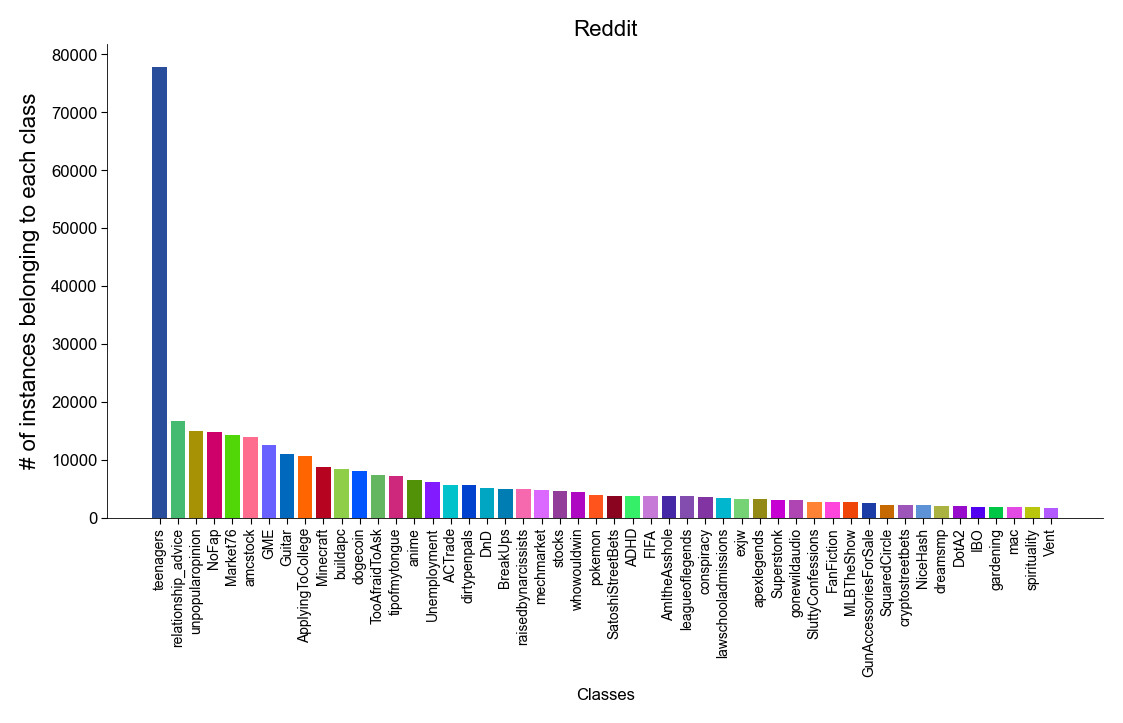

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=200, layout="constrained")
n = 50
ax.bar(
    np.arange(n),
    np.flip(np.sort(counts))[:n],
    color=np.array(list(dict_label_to_color.values()))[
        np.flip(np.argsort(counts))
    ],
)

ax.set_xticks(
    np.arange(n),
    labels=unique_labels[np.flip(np.argsort(counts))[:n]],
    rotation="vertical",
    fontsize=5,
)
ax.set_ylabel("# of instances belonging to each class", fontsize=8)
ax.set_xlabel("Classes")
ax.set_title("Reddit")


fig.savefig(figures_path / "barplot_class_distribution_reddit.png")

### ICLR

In [ ]:
# %%time
# iclr2024 = pd.read_parquet(
#     data_path / "iclr2024.parquet.gzip",
#     # index=False,
#     engine="pyarrow",
#     # compression="gzip",
# )

In [ ]:
labels_iclr = np.load(variables_path / "updated_dataset" / "labels_iclr.npy")
colors_iclr = np.load(variables_path / "updated_dataset" / "colors_iclr.npy")

pickle_in = open(
    variables_path / "updated_dataset" / "dict_label_to_color.pkl", "rb"
)
dict_label_to_color = pickle.load(pickle_in)

In [ ]:
dict_label_to_color

{'CNNs': '#d21820',
 'GANs': '#1869ff',
 'RNNs': '#008a00',
 'ViTs': '#f36dff',
 'active learning': '#710079',
 'adversarial': '#eba600',
 'anomaly detection': '#00bec2',
 'autoencoders': '#5d3d04',
 'causality': '#005559',
 'clustering': '#45ef3d',
 'compression': '#a2aeff',
 'continual learning': '#ff8e92',
 'contrastive learning': '#9e6586',
 'diffusion models': '#9e28ff',
 'explainability': '#8eae75',
 'fairness': '#aa6d35',
 'federated learning': '#791028',
 'few-shot learning': '#3d3986',
 'graphs': '#f71c96',
 'imitation learning': '#005114',
 'in-context learning': '#55829a',
 'interpretability': '#ff6500',
 'knowledge distillation': '#009271',
 'language models': '#c200c2',
 'llms': '#31ebb2',
 'meta learning': '#e7b6e7',
 'model-based reinforcement learning': '#656d31',
 'multi-agent reinforcement learning': '#8a79ba',
 'multi-task learning': '#08aaf3',
 'neural architecture search': '#c6d20c',
 'object detection': '#ae0069',
 'offline RL': '#9e8e00',
 'optimal transport': '#

In [ ]:
print("# samples", len(labels_iclr))
print("# classes", len(np.unique(labels_iclr)))

# samples 24347
# classes 46


In [ ]:
unique_labels, counts = np.unique(labels_iclr, return_counts=True)

In [ ]:
unique_colors = np.vectorize(dict_label_to_color.get)(
    unique_labels[np.flip(np.argsort(counts))]
)

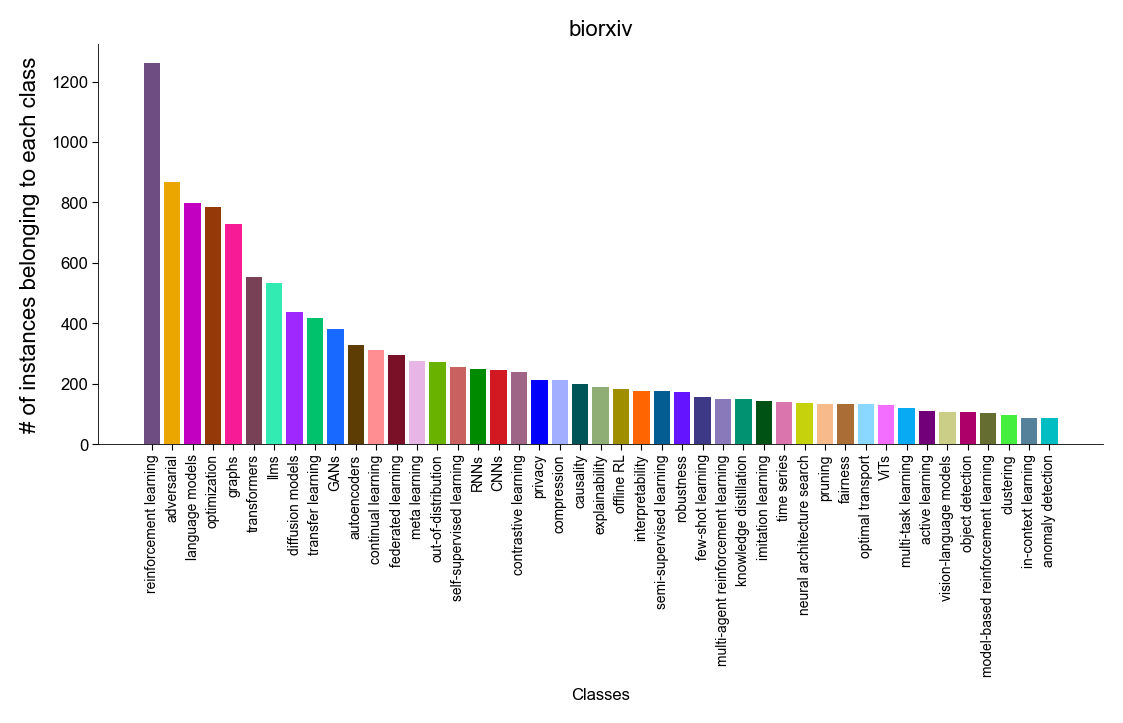

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=200, layout="constrained")

ax.bar(
    np.arange(len(np.unique(labels_iclr)))[1:],
    np.flip(np.sort(counts))[1:],
    color=unique_colors[1:],
)

ax.set_xticks(
    np.arange(len(np.unique(labels_iclr)))[1:],
    labels=unique_labels[np.flip(np.argsort(counts))][1:],
    rotation="vertical",
    fontsize=5,
)
ax.set_ylabel("# of instances belonging to each class", fontsize=8)
ax.set_xlabel("Classes")
ax.set_title(f"{dataset_name}")


fig.savefig(figures_path / f"barplot_class_distribution_iclr_v2.png")

### StackExchange

In [ ]:
dataset_name = "stackexchange"
dataset_path = "mteb/stackexchange-clustering-p2p"

In [ ]:
dataset = load_dataset(dataset_path)

In [ ]:
dataset

DatasetDict({
    test: Dataset({
        features: ['sentences', 'labels'],
        num_rows: 10
    })
})

In [ ]:
sentences = list(
    np.hstack(dataset.data["test"].to_pandas().sentences.to_numpy())
)
labels = list(np.hstack(dataset.data["test"].to_pandas().labels.to_numpy()))

In [ ]:
print("# samples", len(labels))
print("# classes", len(np.unique(labels)))

# samples 75000
# classes 610


In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)

In [ ]:
unique_labels

array(['.net', '2.5d', '2d', '3d', '3d-meshes', '3d-modeling', '3dsmax',
       'aabb', 'accessibility', 'actionscript', 'actionscript-3',
       'adventure-game-studio', 'adventure-games', 'advertisements', 'ai',
       'ajax', 'algorithm', 'allegro', 'alpha', 'alpha-blending',
       'analytics', 'andengine', 'android', 'android-studio',
       'angelscript', 'angles', 'animation', 'anti-cheat', 'antialiasing',
       'appstore', 'architecture', 'arma3', 'art', 'artemis',
       'aspect-ratio', 'assembly', 'asset-management', 'assets', 'assimp',
       'audio', 'augmented-reality', 'authentication', 'automation',
       'avatar', 'awesomium', 'babylonjs', 'balance',
       'barycentric-coordinates', 'behavior', 'behavior-tree', 'beta',
       'beziers', 'blender', 'blender-game-engine', 'board-game', 'books',
       'bot', 'bounding-boxes', 'bounding-spheres', 'box2d', 'browser',
       'browser-based-games', 'bsp', 'bukkit', 'bullet-physics',
       'business', 'business-model', 'c'

In [ ]:
dataset_name = "stackexchange"
colors = np.load(
    variables_path / "updated_dataset" / f"colors_{dataset_name}.npy"
)
pickle_in = open(
    variables_path
    / "updated_dataset"
    / f"dict_label_to_color_{dataset_name}.pkl",
    "rb",
)
dict_label_to_color = pickle.load(pickle_in)

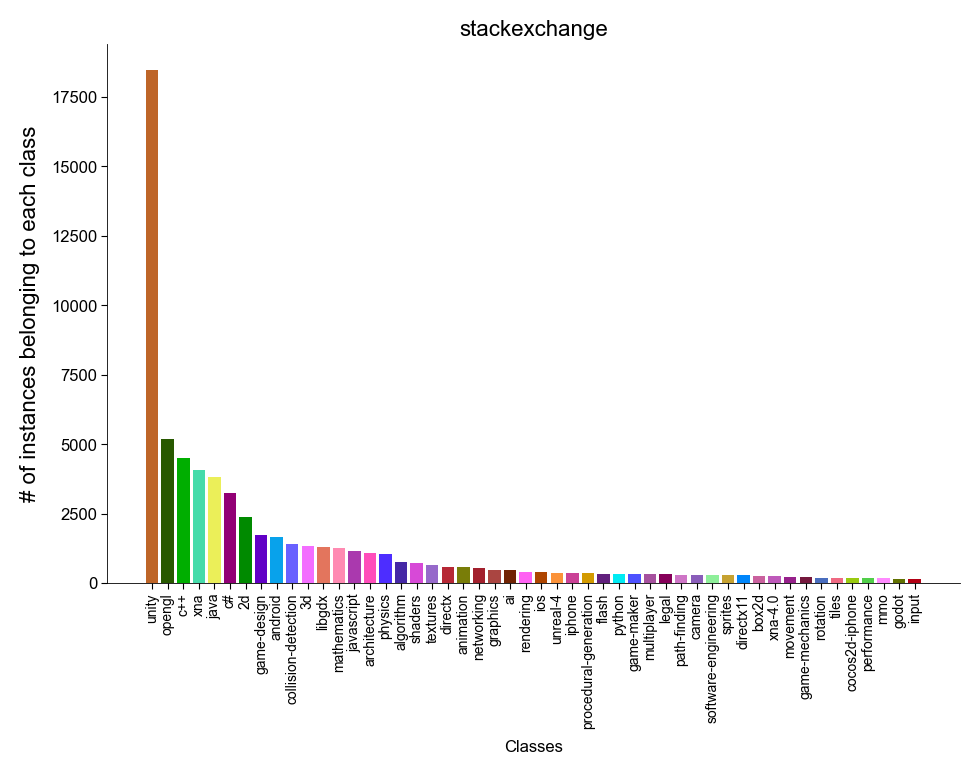

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=200)
n = 50
ax.bar(
    np.arange(n),
    np.flip(np.sort(counts))[:n],
    color=np.array(list(dict_label_to_color.values()))[
        np.flip(np.argsort(counts))
    ],
)

ax.set_xticks(
    np.arange(n),
    labels=unique_labels[np.flip(np.argsort(counts))[:n]],
    rotation="vertical",
    fontsize=5,
)
ax.set_ylabel("# of instances belonging to each class", fontsize=8)
ax.set_xlabel("Classes")
ax.set_title(f"{dataset_name}")


fig.savefig(figures_path / f"barplot_class_distribution_{dataset_name}.png")

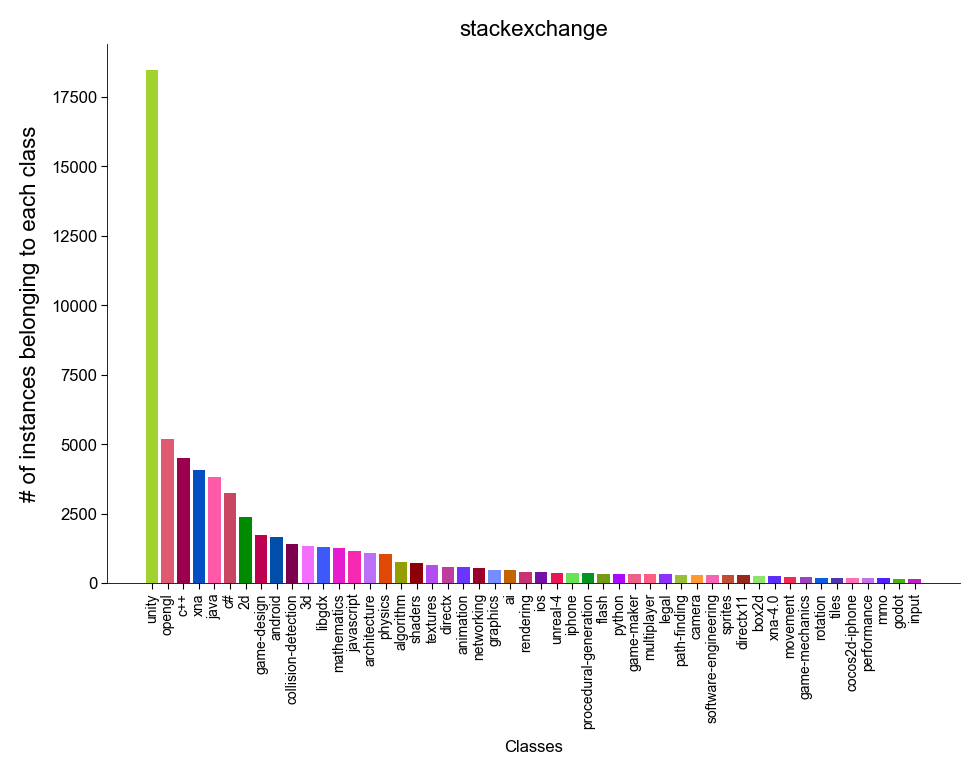

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=200)
n = 50
ax.bar(
    np.arange(n),
    np.flip(np.sort(counts))[:n],
    color=np.array(list(dict_label_to_color.values()))[
        np.flip(np.argsort(counts))
    ],
)

ax.set_xticks(
    np.arange(n),
    labels=unique_labels[np.flip(np.argsort(counts))[:n]],
    rotation="vertical",
    fontsize=5,
)
ax.set_ylabel("# of instances belonging to each class", fontsize=8)
ax.set_xlabel("Classes")
ax.set_title(f"{dataset_name}")


fig.savefig(figures_path / f"barplot_class_distribution_{dataset_name}.png")

## kNN accuracy

In [ ]:
model_names = [
    "MPNet",
    "SimCSE",
    "SPECTER",
    "SciNCL",
    "SBERT",
    "BGE-base",
    "BGE-large",
]

In [ ]:
datasets_names = ["biorxiv", "medrxiv", "reddit", "stackexchange"]

In [ ]:
results = pd.DataFrame(
    columns=[
        "MPNet",
        "SimCSE",
        "SPECTER",
        "SciNCL",
        # "EmbddR",
        "EmbddR10",
        # "RandomBERT",
        "RandomBERT10",
        "Dropout",
        "Crops",
        "SBERT",
        "BGE-base",
        "BGE-large",
        # "TF-IDF",
        # "SVD",
        # "L2(SVD)",
    ],
    index=["ICLR", "arxiv_secondary"] + datasets_names,
)
for dataset_name in datasets_names:
    # baseline
    for model_name in model_names:
        saving_path = Path("embeddings_" + model_name.lower()) / Path(
            f"updated_dataset/mteb_datasets/{dataset_name}"
        )

        results.loc[dataset_name, model_name] = np.load(
            variables_path / saving_path / "knn_accuracies_baseline.npy",
        )[0]

    # fine tuned models
    saving_path = Path("embeddings_mpnet") / Path(
        f"updated_dataset/mteb_datasets/{dataset_name}"
    )
    results.loc[dataset_name, "Crops"] = np.load(
        variables_path / saving_path / "knn_accuracies_run1.npy",
    )[0][0]

    # dropout
    results.loc[dataset_name, "Dropout"] = np.load(
        variables_path / saving_path / "knn_accuracies_run2.npy",
    )[0][0]

    # embedding layer
    saving_path = Path("embeddings_random_bert") / Path(
        f"updated_dataset/embedding_layer_experiment/mteb_datasets/{dataset_name}"
    )
    # results["EmbddR"].loc[dataset_name] = np.load(
    #     variables_path / saving_path / "knn_accuracies_run3.npy",
    # )[0][0]
    results.loc[dataset_name, "EmbddR10"] = np.load(
        variables_path / saving_path / "knn_accuracies_run3_10_epochs.npy",
    )[-1][0]

    # random BERT
    saving_path = Path("embeddings_random_bert") / Path(
        f"updated_dataset/mteb_datasets/{dataset_name}"
    )
    # results["RandomBERT"].loc[dataset_name] = np.load(
    #     variables_path / saving_path / "knn_accuracies_run5.npy",
    # )[0][
    #     0
    # ]
    results.loc[dataset_name, "RandomBERT10"] = np.load(
        variables_path / saving_path / "knn_accuracies_run5.npy",
    )[-1][0]

    # # TF-IDF
    # results["TF-IDF"].loc[dataset_name] = np.load(
    #     variables_path
    #     / "updated_dataset"
    #     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}.npy",
    # )[0]
    # results["SVD"].loc[dataset_name] = np.load(
    #     variables_path
    #     / "updated_dataset"
    #     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}.npy",
    # )[1]
    # results["L2(SVD)"].loc[dataset_name] = np.load(
    #     variables_path
    #     / "updated_dataset"
    #     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}.npy",
    # )[2]

In [ ]:
results.loc["ICLR"] = np.zeros(len(results.iloc[0]))
results_iclr = {
    "MPNet": 0.374,
    "SimCSE": 0.457,
    "SciNCL": 0.570,
    "SPECTER": 0.568,
    # "EmbddR": 0.548,  # already updated values with only layer (not module)
    "EmbddR10": 0.573,  # already updated values with only layer (not module)
    # "RandomBERT": 0.471,  # !
    "RandomBERT10": 0.571,  # !
    "Dropout": 0.468,
    "Crops": 0.589,
    "SBERT": 0.633,
    "BGE-base": 0.633,
    "BGE-large": 0.635,
    # "TF-IDF": 0.600,
    # "SVD": 0.606,
    # "L2(SVD)": 0.624,
}

for key, value in results_iclr.items():
    results.loc["ICLR", key] = value

In [ ]:
# add Arxiv
dataset_name = "arxiv"
# baseline

# results.loc["arxiv_main"] = np.zeros(len(results.iloc[0]))
results.loc["arxiv_secondary"] = np.zeros(len(results.iloc[0]))

for model_name in model_names:
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        f"updated_dataset/mteb_datasets/{dataset_name}"
    )

    # results.loc["arxiv_main", model_name] = np.load(
    #     variables_path / saving_path / "knn_accuracies_baseline_main.npy",
    # )[0]
    results.loc["arxiv_secondary", model_name] = np.load(
        variables_path / saving_path / "knn_accuracies_baseline_secondary.npy",
    )[0]

# fine tuned models
saving_path = Path("embeddings_mpnet") / Path(
    f"updated_dataset/mteb_datasets/{dataset_name}"
)
# results.loc["arxiv_main", "Crops"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run1_main.npy",
# )[0][0]
results.loc["arxiv_secondary", "Crops"] = np.load(
    variables_path / saving_path / "knn_accuracies_run1_secondary.npy",
)[0]


# dropout
# results.loc["arxiv_main", "Dropout"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run2_main.npy",
# )[0][0]
results.loc["arxiv_secondary", "Dropout"] = np.load(
    variables_path / saving_path / "knn_accuracies_run2_secondary.npy",
)[0]

# embedding layer
saving_path = Path("embeddings_random_bert") / Path(
    f"updated_dataset/embedding_layer_experiment/mteb_datasets/{dataset_name}"
)
# results["EmbddR"].loc["arxiv_main"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run3_main.npy",
# )[0][0]
# results["EmbddR"].loc["arxiv_secondary"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run3_secondary.npy",
# )[0]
# results["EmbddR10"].loc["arxiv_main"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run3_10_epochs_main.npy",
# )[0][0]
results.loc["arxiv_secondary", "EmbddR10"] = np.load(
    variables_path
    / saving_path
    / "knn_accuracies_run3_10_epochs_secondary.npy",
)[0]

# RandomBERT
saving_path = Path("embeddings_random_bert") / Path(
    f"updated_dataset/mteb_datasets/{dataset_name}"
)
# results["RandomBERT"].loc["arxiv_main"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run5_main.npy",
# )[0][0]
# results["RandomBERT"].loc["arxiv_secondary"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run5_secondary.npy",
# )[0]
# results["RandomBERT10"].loc["arxiv_main"] = np.load(
#     variables_path / saving_path / "knn_accuracies_run5_main.npy",
# )[-1][0]
results.loc["arxiv_secondary", "RandomBERT10"] = np.load(
    variables_path / saving_path / "knn_accuracies_run5_secondary.npy",
)[-1]

# # TF-IDF
# results["TF-IDF"].loc["arxiv_main"] = np.load(
#     variables_path
#     / "updated_dataset"
#     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}_main.npy",
# )[0]
# results["TF-IDF"].loc["arxiv_secondary"] = np.load(
#     variables_path
#     / "updated_dataset"
#     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}_secondary.npy",
# )[0]
# results["SVD"].loc["arxiv_main"] = np.load(
#     variables_path
#     / "updated_dataset"
#     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}_main.npy",
# )[1]
# results["SVD"].loc["arxiv_secondary"] = np.load(
#     variables_path
#     / "updated_dataset"
#     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}_secondary.npy",
# )[1]
# results["L2(SVD)"].loc["arxiv_main"] = np.load(
#     variables_path
#     / "updated_dataset"
#     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}_main.npy",
# )[2]
# results["L2(SVD)"].loc["arxiv_secondary"] = np.load(
#     variables_path
#     / "updated_dataset"
#     / f"knn_accuracy_tfidf_svd_l2_{dataset_name}_secondary.npy",
# )[2]

In [ ]:
results

,MPNet,SimCSE,SPECTER,SciNCL,EmbddR10,RandomBERT10,Dropout,Crops,SBERT,BGE-base,BGE-large
ICLR,0.374,0.457,0.568,0.57,0.573,0.571,0.468,0.589,0.633,0.633,0.635
arxiv_secondary,0.377915,0.400188,0.4418,0.451749,0.433748,0.443233,0.399192,0.442318,0.461548,0.460442,0.460442
biorxiv,0.586168,0.590444,0.648076,0.663692,0.607362,0.605689,0.606804,0.617773,0.652352,0.644172,0.655326
medrxiv,0.435127,0.471955,0.526346,0.528045,0.491218,0.448725,0.47762,0.523513,0.567705,0.556941,0.552975
reddit,0.626426,0.599456,0.552003,0.572769,0.636308,0.618198,0.577993,0.719634,0.749913,0.792381,0.800087
stackexchange,0.392933,0.407467,0.414533,0.429333,0.452133,0.454133,0.415733,0.456133,0.5056,0.514,0.514933


In [ ]:
results.astype(float).round(3) * 100

,MPNet,SimCSE,SPECTER,SciNCL,EmbddR10,RandomBERT10,Dropout,Crops,SBERT,BGE-base,BGE-large
ICLR,37.4,45.7,56.8,57.0,57.3,57.1,46.8,58.9,63.3,63.3,63.5
arxiv_secondary,37.8,40.0,44.2,45.2,43.4,44.3,39.9,44.2,46.2,46.0,46.0
biorxiv,58.6,59.0,64.8,66.4,60.7,60.6,60.7,61.8,65.2,64.4,65.5
medrxiv,43.5,47.2,52.6,52.8,49.1,44.9,47.8,52.4,56.8,55.7,55.3
reddit,62.6,59.9,55.2,57.3,63.6,61.8,57.8,72.0,75.0,79.2,80.0
stackexchange,39.3,40.7,41.5,42.9,45.2,45.4,41.6,45.6,50.6,51.4,51.5


### Table 2

In [ ]:
results = results.astype(float).round(3)

results[
    [
        "MPNet",
        "SimCSE",
        "Dropout",
        "Crops",
        "SBERT",
        "BGE-base",
        "BGE-large",
    ]
] * 100

,MPNet,SimCSE,Dropout,Crops,SBERT,BGE-base,BGE-large
ICLR,37.4,45.7,46.8,58.9,63.3,63.3,63.5
arxiv_secondary,37.8,40.0,39.9,44.2,46.2,46.0,46.0
biorxiv,58.6,59.0,60.7,61.8,65.2,64.4,65.5
medrxiv,43.5,47.2,47.8,52.4,56.8,55.7,55.3
reddit,62.6,59.9,57.8,72.0,75.0,79.2,80.0
stackexchange,39.3,40.7,41.6,45.6,50.6,51.4,51.5


In [ ]:
results[
    [
        "MPNet",
        "SimCSE",
        "Dropout",
        "Crops",
        "SBERT",
        "BGE-base",
        "BGE-large",
    ]
].mean(axis=0).round(3) * 100

MPNet        46.5
SimCSE       48.8
Dropout      49.1
Crops        55.8
SBERT        59.5
BGE-base     60.0
BGE-large    60.3
dtype: float64

### Table S6

In [ ]:
results = results.astype(float).round(3)

results[
    [
        "Dropout",
        "Crops",
        "SPECTER",
        "SciNCL",
        "RandomBERT10",
        "EmbddR10",
    ]
] * 100

,Dropout,Crops,SPECTER,SciNCL,RandomBERT10,EmbddR10
ICLR,46.8,58.9,56.8,57.0,57.1,57.3
arxiv_secondary,39.9,44.2,44.2,45.2,44.3,43.4
biorxiv,60.7,61.8,64.8,66.4,60.6,60.7
medrxiv,47.8,52.4,52.6,52.8,44.9,49.1
reddit,57.8,72.0,55.2,57.3,61.8,63.6
stackexchange,41.6,45.6,41.5,42.9,45.4,45.2


In [ ]:
results[
    [
        "Dropout",
        "Crops",
        "SPECTER",
        "SciNCL",
        "RandomBERT10",
        "EmbddR10",
    ]
].mean(axis=0).round(3) * 100

Dropout         49.1
Crops           55.8
SPECTER         52.5
SciNCL          53.6
RandomBERT10    52.4
EmbddR10        53.2
dtype: float64

# Layers MTEB evaluation

## Pre-trained MPNet

In [ ]:
# IMPORT RESULTS
model_name = "MPNet"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)

mteb_scores_layers_model = pd.DataFrame()

for layer_number in np.arange(13):
    # layer_number = 12
    saving_path = (
        Path("embeddings_" + model_name.lower())
        / Path("updated_dataset")
        / Path("mteb_benchmark")
        / Path("eval_layers")
        / Path(saving_dir_str)
        / Path(f"layer_{layer_number}")
    )
    root_directory = variables_path / saving_path
    mteb_results_model = load_mteb_results(root_directory)

    # unpack
    mteb_scores_model = create_results_dict(mteb_results_model)

    mteb_scores_layers_model[layer_number] = mteb_scores_model

mteb_scores_layers_mpnet = mteb_scores_layers_model.T

In [ ]:
mteb_scores_layers_mpnet

,AmazonPolarityClassification,ArguAna,ArxivClusteringP2P,Banking77Classification,BiorxivClusteringP2P,ImdbClassification,MTOPDomainClassification,MassiveIntentClassification,MassiveScenarioClassification,MedrxivClusteringP2P,MindSmallReranking,RedditClusteringP2P,SCIDOCS,STS15,STS16,STSBenchmark,SciDocsRR,StackExchangeClusteringP2P,TweetSentimentExtractionClassification
0,0.622958,0.34075,0.238123,0.699643,0.218026,0.552372,0.860762,0.613954,0.655313,0.210413,0.270333,0.273557,0.05748,0.742692,0.686107,0.633244,0.676749,0.229795,0.498896
1,0.648317,0.33148,0.260717,0.671104,0.253289,0.578176,0.849088,0.604405,0.640182,0.232454,0.293889,0.341346,0.02431,0.721731,0.655231,0.583329,0.666582,0.247153,0.517883
2,0.653211,0.28885,0.268973,0.653604,0.253067,0.583332,0.837346,0.593578,0.632078,0.236923,0.283086,0.368180,0.01344,0.674465,0.652893,0.554007,0.630935,0.251976,0.517629
3,0.674060,0.25558,0.264569,0.660000,0.242690,0.594804,0.827930,0.603833,0.638500,0.230613,0.281777,0.364578,0.01257,0.683329,0.646372,0.561185,0.627101,0.249242,0.523939
4,0.697055,0.24072,0.260083,0.664935,0.232044,0.608764,0.819061,0.599798,0.639240,0.222035,0.280419,0.354656,0.01158,0.676184,0.636366,0.563437,0.615694,0.245397,0.534720
5,0.708475,0.23804,0.251286,0.655195,0.222993,0.627736,0.807889,0.592266,0.627976,0.215534,0.283478,0.333902,0.00822,0.665067,0.620642,0.564646,0.601129,0.241370,0.543152
6,0.762176,0.21325,0.245970,0.644123,0.213241,0.687012,0.793730,0.577606,0.618393,0.209221,0.280049,0.346821,0.00675,0.637176,0.614565,0.549330,0.585093,0.238081,0.551245
7,0.776562,0.19181,0.242547,0.628019,0.207542,0.704156,0.778363,0.567518,0.607061,0.201846,0.276525,0.349362,0.00696,0.602605,0.609681,0.523514,0.567964,0.234907,0.554924
8,0.780894,0.20412,0.243564,0.640455,0.207016,0.700684,0.791359,0.579590,0.623268,0.207649,0.283198,0.366650,0.00773,0.615948,0.620602,0.538271,0.578332,0.237590,0.558263
9,0.755956,0.22083,0.259655,0.651396,0.226515,0.690968,0.806658,0.591964,0.641560,0.216421,0.284972,0.402686,0.00925,0.637528,0.634204,0.557995,0.584687,0.244786,0.557187


0     0.447480
1     0.444543
2     0.429957
3     0.427060
4     0.422864
5     0.417410
6     0.411127
7     0.401397
8     0.409716
9     0.420121
10    0.430475
11    0.449224
12    0.389194
dtype: float64


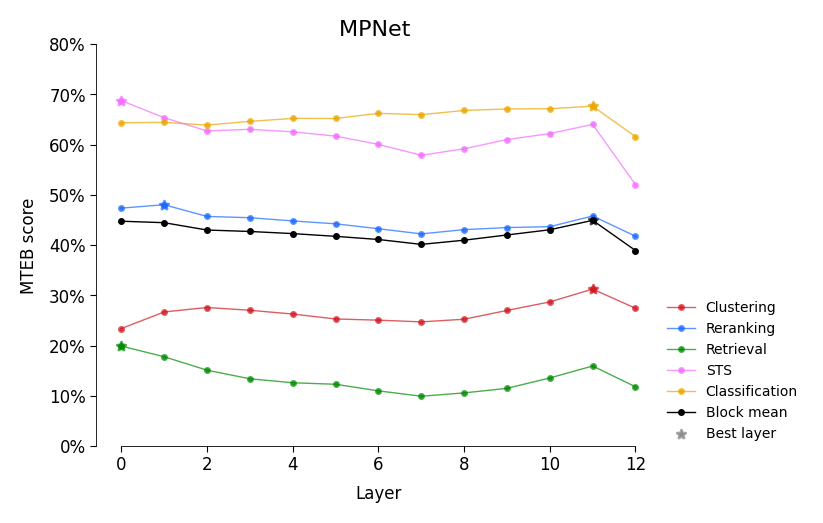

In [ ]:
%matplotlib inline


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")

# change with model:
model_name = "MPNet"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_mpnet

# calculate block means
df_block_mean = pd.DataFrame()
df_block_mean["clustering"] = df_model[
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ]
].mean(axis=1)

df_block_mean["reranking"] = df_model[
    ["SciDocsRR", "MindSmallReranking"]
].mean(axis=1)
df_block_mean["retrieval"] = df_model[["SCIDOCS", "ArguAna"]].mean(axis=1)
df_block_mean["sts"] = df_model[["STS15", "STS16", "STSBenchmark"]].mean(
    axis=1
)
df_block_mean["classification"] = df_model[
    [
        "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ]
].mean(axis=1)

# create palette
palette = glasbey.create_palette(
    palette_size=len(df_block_mean.columns) + 1,
    lightness_bounds=(20, 75),
    chroma_bounds=(50, 90),
)


for i, elem in enumerate(df_block_mean.columns):
    if elem == "classification":
        i = i + 1
    ax.plot(
        df_block_mean.index,
        df_block_mean[elem],
        label=[elem.upper() if elem == "sts" else elem.capitalize()],
        c=palette[i],
        alpha=0.7,
        marker=".",
        ms=3,
    )
    ax.scatter(
        df_block_mean.index[np.argmax(df_block_mean[elem])],
        np.amax(df_block_mean[elem]),
        c=palette[i],
        alpha=0.7,
        marker="*",
        s=10,
    )


ax.plot(
    df_block_mean.index,
    df_block_mean.mean(axis=1),
    label="Block mean",
    c="k",
    # lw=1,
    marker=".",
    ms=3,
)
ax.scatter(
    df_block_mean.index[np.argmax(df_block_mean.mean(axis=1))],
    np.amax(df_block_mean.mean(axis=1)),
    c="k",
    alpha=0.7,
    marker="*",
    s=10,
)
ax.scatter(
    [],
    [],
    c="grey",
    alpha=0.7,
    marker="*",
    s=10,
    label="Best layer",
)
print(df_block_mean.mean(axis=1))

ax.set_title(f"{model_name} {finetune_type}")
ax.legend(loc=(1, 0))
ax.set_ylim(0, 0.8)
ax.set_xticks(np.arange(7) * 2)
ax.set_xlabel("Layer")
ax.set_ylabel("MTEB score")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.spines.bottom.set_bounds(0, 12)

fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}_v3.png")
fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}_v3.pdf")

In [ ]:
df_block_mean

,clustering,reranking,retrieval,sts,classification
0,0.233983,0.473541,0.199115,0.687347,0.643414
1,0.266992,0.480235,0.177895,0.653430,0.644165
2,0.275824,0.457011,0.151145,0.627122,0.638683
3,0.270339,0.454439,0.134075,0.630295,0.646152
4,0.262843,0.448057,0.126150,0.625329,0.651939
5,0.253017,0.442303,0.123130,0.616785,0.651813
6,0.250667,0.432571,0.110000,0.600357,0.662041
7,0.247241,0.422245,0.099385,0.578600,0.659515
8,0.252494,0.430765,0.105925,0.591607,0.667787
9,0.270013,0.434830,0.115040,0.609909,0.670813


MPNet:
1st layers: STS, classification, mean, Retrieval, reranking (2nd layer)
2nd to last : Clustering

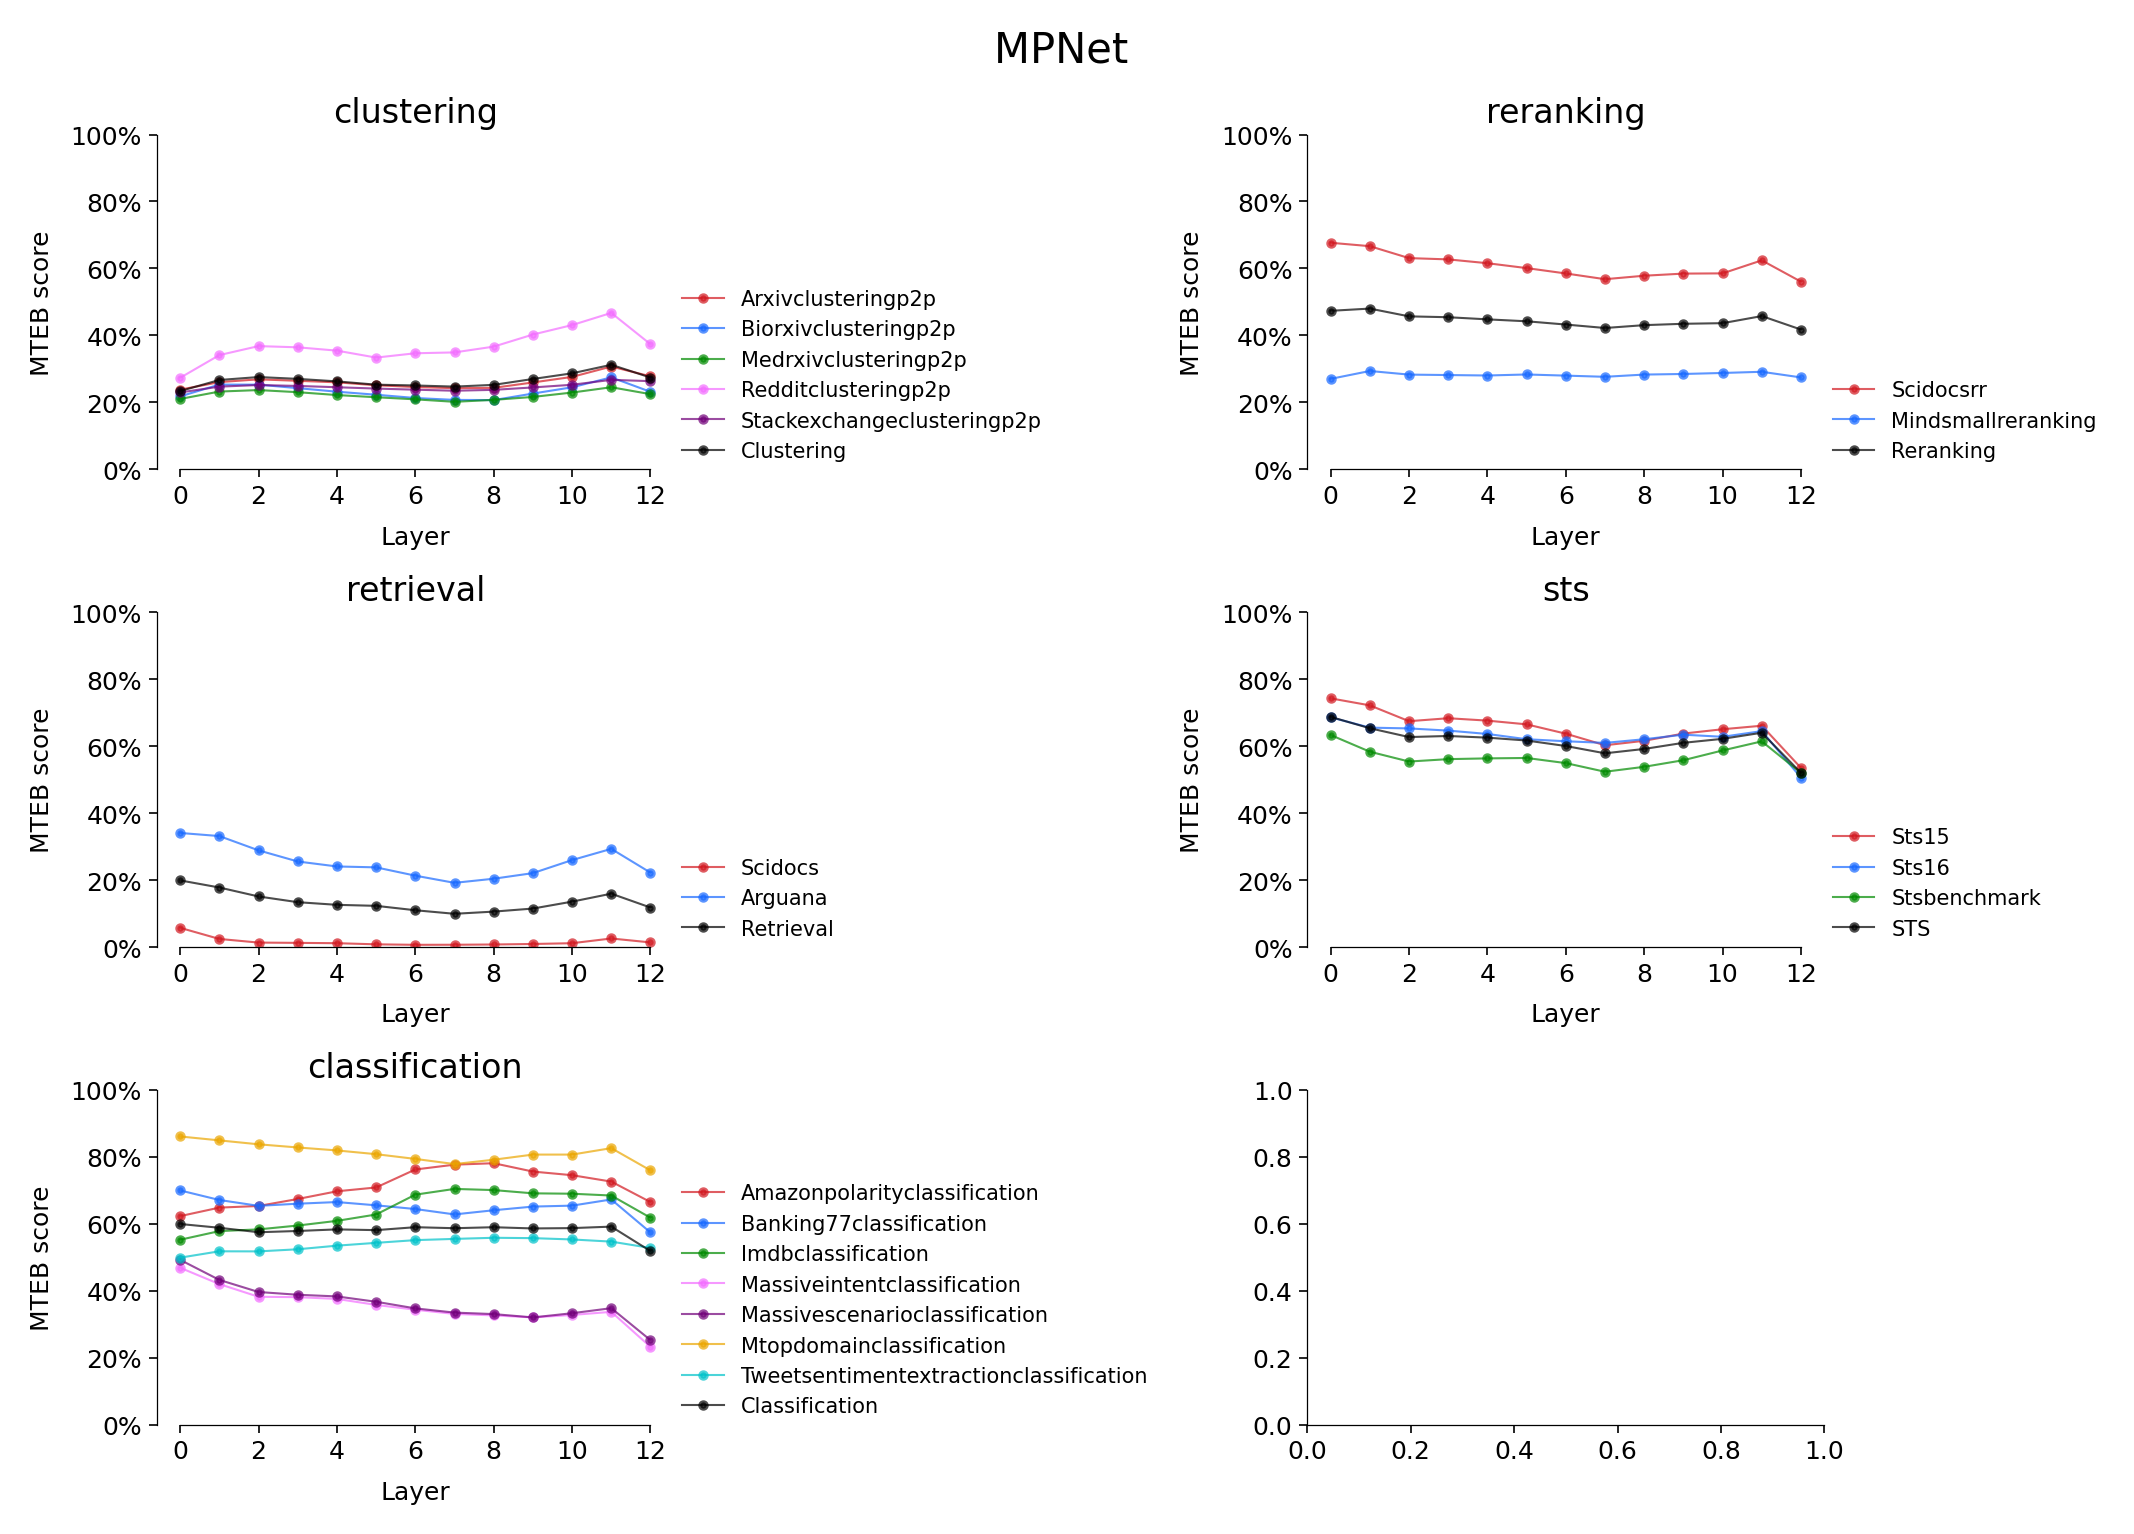

In [ ]:
%matplotlib inline


fig, axes = plt.subplots(3, 2, figsize=(7, 5), dpi=300, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")
axs = axes.flatten()

# change with model:
model_name = "MPNet"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_mpnet

modalities_names = [
    "clustering",
    "reranking",
    "retrieval",
    "sts",
    "classification",
]
modalities = [
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ],
    ["SciDocsRR", "MindSmallReranking"],
    ["SCIDOCS", "ArguAna"],
    ["STS15", "STS16", "STSBenchmark"],
    [
        "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ],
]

df_block_mean = pd.DataFrame()

for j, mod in enumerate(modalities_names):
    tasks = modalities[j]
    df_modality = df_model[tasks]

    palette = glasbey.create_palette(
        palette_size=len(df_modality.columns) + 1,
        lightness_bounds=(20, 75),
        chroma_bounds=(50, 90),
    )

    for i, elem in enumerate(df_modality.columns):
        axs[j].plot(
            df_modality.index,
            df_modality[elem],
            label=[elem.capitalize()],
            c=palette[i],
            alpha=0.7,
            marker=".",
            ms=3,
        )

    df_block_mean[mod] = df_modality.mean(axis=1)

    axs[j].plot(
        df_block_mean.index,
        df_block_mean[mod],
        label=[mod.upper() if mod == "sts" else mod.capitalize()],
        c="k",
        alpha=0.7,
        marker=".",
        ms=3,
    )

    axs[j].set_title(f"{mod}")
    axs[j].legend(loc=(1, 0))
    axs[j].set_ylim(0, 1)
    axs[j].set_xticks(np.arange(7) * 2)
    axs[j].set_xlabel("Layer")
    axs[j].set_ylabel("MTEB score")
    axs[j].yaxis.set_major_formatter(
        ticker.PercentFormatter(xmax=1, decimals=0)
    )
    axs[j].spines.bottom.set_bounds(0, 12)

fig.suptitle(f"{model_name} {finetune_type}", fontsize=10)

fig.savefig(figures_path / f"mteb_modalities_layers_{saving_dir_str}.png")
# fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}.pdf")

## Fine-tuned MPNet (crops)

In [ ]:
# IMPORT RESULTS
model_name = "MPNet"
finetune_type = "crops"
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)

mteb_scores_layers_model = pd.DataFrame()

for layer_number in np.arange(13):
    # layer_number = 12
    saving_path = (
        Path("embeddings_" + model_name.lower())
        / Path("updated_dataset")
        / Path("mteb_benchmark")
        / Path("eval_layers")
        / Path(saving_dir_str)
        / Path(f"layer_{layer_number}")
    )
    root_directory = variables_path / saving_path
    mteb_results_model = load_mteb_results(root_directory)

    # unpack
    mteb_scores_model = create_results_dict(mteb_results_model)

    mteb_scores_layers_model[layer_number] = mteb_scores_model

mteb_scores_layers_mpnet_crops = mteb_scores_layers_model.T

In [ ]:
mteb_scores_layers_mpnet_crops

,AmazonPolarityClassification,ArguAna,ArxivClusteringP2P,Banking77Classification,BiorxivClusteringP2P,ImdbClassification,MTOPDomainClassification,MassiveIntentClassification,MassiveScenarioClassification,MedrxivClusteringP2P,MindSmallReranking,RedditClusteringP2P,SCIDOCS,STS15,STS16,STSBenchmark,SciDocsRR,StackExchangeClusteringP2P,TweetSentimentExtractionClassification
0,0.622924,0.34132,0.237957,0.699545,0.222137,0.552348,0.860807,0.613954,0.655245,0.210008,0.270389,0.271000,0.05741,0.742643,0.686289,0.633473,0.676933,0.228705,0.499038
1,0.648128,0.33453,0.260185,0.671948,0.252662,0.577528,0.849704,0.605111,0.640383,0.235253,0.292873,0.332135,0.02367,0.722557,0.655146,0.583675,0.669353,0.248216,0.518138
2,0.655209,0.28628,0.266203,0.658214,0.252622,0.583616,0.840857,0.598117,0.634667,0.235041,0.284308,0.363489,0.01346,0.680495,0.655054,0.559481,0.638632,0.247360,0.517233
3,0.679217,0.26285,0.264145,0.666526,0.244542,0.595304,0.833675,0.606859,0.640720,0.230349,0.279503,0.350326,0.01193,0.691847,0.653521,0.571734,0.635896,0.245271,0.527844
4,0.707355,0.24624,0.257063,0.677110,0.236136,0.611640,0.832262,0.606994,0.644284,0.224045,0.281098,0.335649,0.01173,0.694313,0.647139,0.587019,0.627571,0.241049,0.541653
5,0.723410,0.24629,0.250985,0.678312,0.228112,0.632952,0.830803,0.609213,0.641527,0.215584,0.283169,0.318977,0.01021,0.690846,0.636373,0.589985,0.623999,0.239319,0.554018
6,0.763912,0.23263,0.249610,0.677045,0.222628,0.684380,0.828295,0.607061,0.639206,0.213376,0.282198,0.334111,0.00933,0.671847,0.630707,0.574627,0.612803,0.237838,0.556565
7,0.766536,0.21583,0.243323,0.662110,0.216022,0.696648,0.818354,0.602286,0.631910,0.209489,0.280355,0.329246,0.00985,0.638157,0.620964,0.544076,0.597391,0.233427,0.558036
8,0.779534,0.24368,0.257282,0.683442,0.231606,0.707076,0.835317,0.619401,0.653026,0.214946,0.286415,0.378714,0.01330,0.656962,0.639835,0.564309,0.614165,0.238769,0.562790
9,0.758475,0.28366,0.282233,0.712045,0.254947,0.704936,0.859530,0.635810,0.683524,0.232530,0.290365,0.421395,0.02110,0.694828,0.673107,0.595669,0.632171,0.253302,0.563413


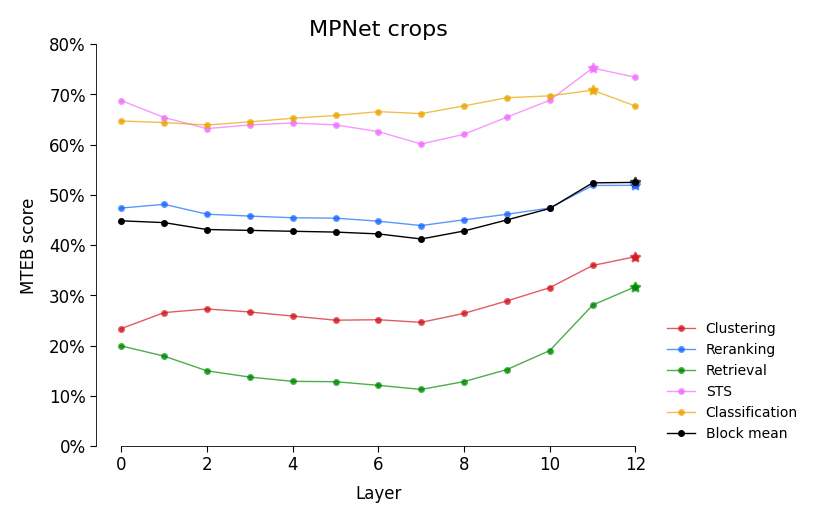

In [ ]:
%matplotlib inline


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")

# change with model:
model_name = "MPNet"
finetune_type = "crops"
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_mpnet_crops

# calculate block means
df_block_mean = pd.DataFrame()
df_block_mean["clustering"] = df_model[
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ]
].mean(axis=1)

df_block_mean["reranking"] = df_model[
    ["SciDocsRR", "MindSmallReranking"]
].mean(axis=1)
df_block_mean["retrieval"] = df_model[["SCIDOCS", "ArguAna"]].mean(axis=1)
df_block_mean["sts"] = df_model[["STS15", "STS16", "STSBenchmark"]].mean(
    axis=1
)
df_block_mean["classification"] = df_model[
    [
        # "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ]
].mean(axis=1)

# create palette
palette = glasbey.create_palette(
    palette_size=len(df_block_mean.columns) + 1,
    lightness_bounds=(20, 75),
    chroma_bounds=(50, 90),
)


for i, elem in enumerate(df_block_mean.columns):
    if elem == "classification":
        i = i + 1
    ax.plot(
        df_block_mean.index,
        df_block_mean[elem],
        label=[elem.upper() if elem == "sts" else elem.capitalize()],
        c=palette[i],
        alpha=0.7,
        marker=".",
        ms=3,
    )
    ax.scatter(
        df_block_mean.index[np.argmax(df_block_mean[elem])],
        np.amax(df_block_mean[elem]),
        c=palette[i],
        alpha=0.7,
        marker="*",
        s=10,
    )


ax.plot(
    df_block_mean.index,
    df_block_mean.mean(axis=1),
    label="Block mean",
    c="k",
    # lw=1,
    marker=".",
    ms=3,
)
ax.scatter(
    df_block_mean.index[np.argmax(df_block_mean.mean(axis=1))],
    np.amax(df_block_mean.mean(axis=1)),
    c="k",
    alpha=0.7,
    marker="*",
    s=10,
)

ax.set_title(f"{model_name} {finetune_type}")
ax.legend(loc=(1, 0))
ax.set_ylim(0, 0.8)
ax.set_xticks(np.arange(7) * 2)
ax.set_xlabel("Layer")
ax.set_ylabel("MTEB score")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.spines.bottom.set_bounds(0, 12)

fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}_v2.png")
# fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}.pdf")

## Fine-tuned MPNet (dropout)

In [ ]:
# IMPORT RESULTS
model_name = "MPNet"
finetune_type = "simcse"
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)

mteb_scores_layers_model = pd.DataFrame()

for layer_number in np.arange(13):
    saving_path = (
        Path("embeddings_" + model_name.lower())
        / Path("updated_dataset")
        / Path("mteb_benchmark")
        / Path("eval_layers")
        / Path(saving_dir_str)
        / Path(f"layer_{layer_number}")
    )
    root_directory = variables_path / saving_path
    mteb_results_model = load_mteb_results(root_directory)

    # unpack
    mteb_scores_model = create_results_dict(mteb_results_model)

    mteb_scores_layers_model[layer_number] = mteb_scores_model

mteb_scores_layers_mpnet_dropout = mteb_scores_layers_model.T

In [ ]:
mteb_scores_layers_mpnet_dropout

,AmazonPolarityClassification,ArguAna,ArxivClusteringP2P,Banking77Classification,BiorxivClusteringP2P,ImdbClassification,MTOPDomainClassification,MassiveIntentClassification,MassiveScenarioClassification,MedrxivClusteringP2P,MindSmallReranking,RedditClusteringP2P,SCIDOCS,STS15,STS16,STSBenchmark,SciDocsRR,StackExchangeClusteringP2P,TweetSentimentExtractionClassification
0,0.622954,0.34068,0.238131,0.699545,0.220400,0.552416,0.860762,0.293073,0.320881,0.209605,0.270355,0.275102,0.05751,0.742549,0.685910,0.633245,0.676773,0.228788,0.498868
1,0.648640,0.33345,0.261737,0.671591,0.257284,0.578672,0.849020,0.305817,0.322428,0.232673,0.293784,0.344885,0.02371,0.722178,0.653237,0.583577,0.670054,0.247275,0.517516
2,0.652985,0.29290,0.269134,0.651234,0.255612,0.586692,0.838235,0.300303,0.317687,0.238988,0.284160,0.370498,0.01223,0.676470,0.650296,0.554216,0.632371,0.250216,0.516780
3,0.672880,0.26353,0.265629,0.660552,0.255049,0.601596,0.831669,0.304506,0.319872,0.232273,0.283358,0.372940,0.01221,0.686179,0.650001,0.570054,0.631169,0.251042,0.524505
4,0.696520,0.24422,0.265429,0.666071,0.236893,0.614308,0.825764,0.307229,0.321352,0.224494,0.281641,0.349282,0.01053,0.681620,0.638882,0.575343,0.613623,0.247572,0.535144
5,0.704610,0.23924,0.258871,0.657305,0.226305,0.633608,0.812608,0.298453,0.316241,0.217908,0.283617,0.340836,0.00804,0.676639,0.622232,0.575265,0.601774,0.244479,0.539021
6,0.745277,0.21653,0.253530,0.645260,0.218884,0.696420,0.795303,0.382347,0.378413,0.212009,0.282247,0.338672,0.00772,0.643949,0.613506,0.557643,0.591074,0.241793,0.539955
7,0.759883,0.19881,0.248670,0.631201,0.209885,0.716312,0.789535,0.375723,0.368931,0.209218,0.279306,0.334325,0.00876,0.620869,0.607883,0.540592,0.579966,0.237212,0.546463
8,0.775795,0.25209,0.278373,0.655455,0.242663,0.735760,0.813338,0.366947,0.360289,0.228964,0.291313,0.412435,0.01366,0.651361,0.637772,0.578549,0.602040,0.254081,0.553990
9,0.744551,0.26876,0.289821,0.663312,0.255504,0.725716,0.823028,0.365467,0.357969,0.237393,0.294636,0.435898,0.01605,0.671028,0.643107,0.600058,0.601719,0.267464,0.551104


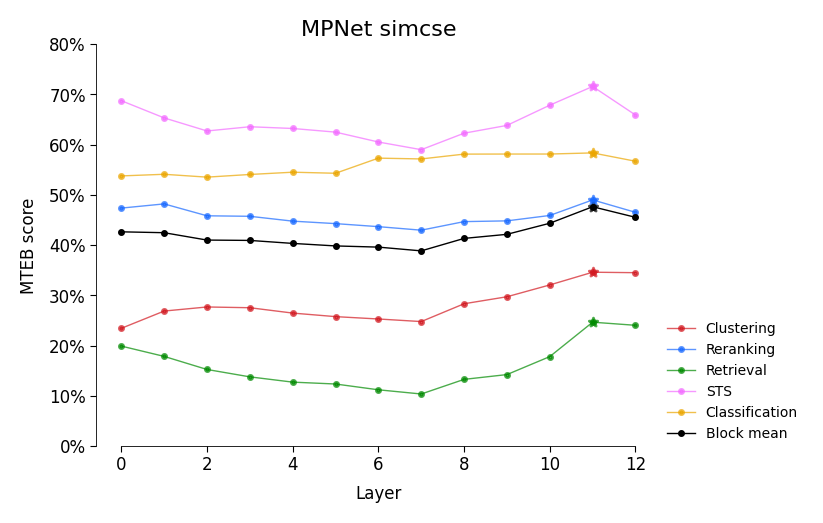

In [ ]:
%matplotlib inline


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")

# change with model:
model_name = "MPNet"
finetune_type = "simcse"
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_mpnet_dropout

# calculate block means
df_block_mean = pd.DataFrame()
df_block_mean["clustering"] = df_model[
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ]
].mean(axis=1)

df_block_mean["reranking"] = df_model[
    ["SciDocsRR", "MindSmallReranking"]
].mean(axis=1)
df_block_mean["retrieval"] = df_model[["SCIDOCS", "ArguAna"]].mean(axis=1)
df_block_mean["sts"] = df_model[["STS15", "STS16", "STSBenchmark"]].mean(
    axis=1
)
df_block_mean["classification"] = df_model[
    [
        "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ]
].mean(axis=1)

# create palette
palette = glasbey.create_palette(
    palette_size=len(df_block_mean.columns) + 1,
    lightness_bounds=(20, 75),
    chroma_bounds=(50, 90),
)


for i, elem in enumerate(df_block_mean.columns):
    if elem == "classification":
        i = i + 1
    ax.plot(
        df_block_mean.index,
        df_block_mean[elem],
        label=[elem.upper() if elem == "sts" else elem.capitalize()],
        c=palette[i],
        alpha=0.7,
        marker=".",
        ms=3,
    )
    ax.scatter(
        df_block_mean.index[np.argmax(df_block_mean[elem])],
        np.amax(df_block_mean[elem]),
        c=palette[i],
        alpha=0.7,
        marker="*",
        s=10,
    )


ax.plot(
    df_block_mean.index,
    df_block_mean.mean(axis=1),
    label="Block mean",
    c="k",
    # lw=1,
    marker=".",
    ms=3,
)
ax.scatter(
    df_block_mean.index[np.argmax(df_block_mean.mean(axis=1))],
    np.amax(df_block_mean.mean(axis=1)),
    c="k",
    alpha=0.7,
    marker="*",
    s=10,
)

ax.set_title(f"{model_name} {finetune_type}")
ax.legend(loc=(1, 0))
ax.set_ylim(0, 0.8)
ax.set_xticks(np.arange(7) * 2)
ax.set_xlabel("Layer")
ax.set_ylabel("MTEB score")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.spines.bottom.set_bounds(0, 12)

fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}_v2.png")
# fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}.pdf")

## Pre-trained BERT

In [ ]:
# IMPORT RESULTS
model_name = "BERT"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}"
)

mteb_scores_layers_model = pd.DataFrame()

for layer_number in np.arange(13):
    # layer_number = 12
    saving_path = (
        Path("embeddings_" + model_name.lower())
        / Path("updated_dataset")
        / Path("mteb_benchmark")
        / Path("eval_layers")
        / Path(saving_dir_str)
        / Path(f"layer_{layer_number}")
    )
    root_directory = variables_path / saving_path
    mteb_results_model = load_mteb_results(root_directory)

    # unpack
    mteb_scores_model = create_results_dict(mteb_results_model)

    mteb_scores_layers_model[layer_number] = mteb_scores_model

mteb_scores_layers_bert = mteb_scores_layers_model.T

In [ ]:
mteb_scores_layers_bert

,AmazonPolarityClassification,ArguAna,ArxivClusteringP2P,Banking77Classification,BiorxivClusteringP2P,ImdbClassification,MTOPDomainClassification,MassiveIntentClassification,MassiveScenarioClassification,MedrxivClusteringP2P,MindSmallReranking,RedditClusteringP2P,SCIDOCS,STS15,STS16,STSBenchmark,SciDocsRR,StackExchangeClusteringP2P,TweetSentimentExtractionClassification
0,0.583441,0.19545,0.166520,0.684123,0.129399,0.536880,0.824761,0.171150,0.223336,0.177658,0.253259,0.188559,0.01092,0.616490,0.553192,0.491713,0.608959,0.211750,0.468110
1,0.642082,0.26795,0.277998,0.705682,0.241990,0.599344,0.865321,0.178178,0.224479,0.225201,0.274696,0.311547,0.05114,0.712389,0.643600,0.581372,0.657151,0.251099,0.490804
2,0.642914,0.27408,0.296014,0.705617,0.261225,0.594576,0.862540,0.180094,0.225151,0.232916,0.273992,0.336970,0.04690,0.686975,0.621909,0.560665,0.653095,0.250497,0.489417
3,0.638204,0.25116,0.286251,0.693409,0.248352,0.581500,0.855176,0.181775,0.228447,0.227809,0.271946,0.314791,0.02452,0.663116,0.609894,0.547734,0.633796,0.246430,0.491200
4,0.633585,0.22706,0.273967,0.682727,0.231227,0.576500,0.850228,0.185373,0.231002,0.216756,0.269746,0.311892,0.01429,0.635039,0.588492,0.521238,0.613918,0.246641,0.497934
5,0.648910,0.21767,0.281594,0.682143,0.230309,0.586272,0.854560,0.189307,0.233726,0.217843,0.276988,0.317603,0.01145,0.640512,0.605810,0.521812,0.609194,0.245418,0.507951
6,0.661102,0.20163,0.271164,0.666721,0.220355,0.595760,0.838281,0.191627,0.236180,0.211595,0.278019,0.308664,0.00818,0.637157,0.615425,0.512152,0.593782,0.241736,0.513413
7,0.674404,0.20025,0.269075,0.669091,0.217096,0.608616,0.838988,0.193107,0.237391,0.213409,0.271829,0.324658,0.00697,0.643374,0.624089,0.512891,0.584668,0.240513,0.518166
8,0.687674,0.19016,0.266449,0.655292,0.215354,0.613588,0.835203,0.194116,0.238568,0.206510,0.268581,0.330197,0.00613,0.642737,0.613928,0.495610,0.579963,0.237946,0.527476
9,0.724560,0.19157,0.274676,0.628701,0.220800,0.635500,0.823871,0.195864,0.238803,0.208663,0.264391,0.343759,0.00734,0.632836,0.600251,0.454945,0.577380,0.243382,0.534975


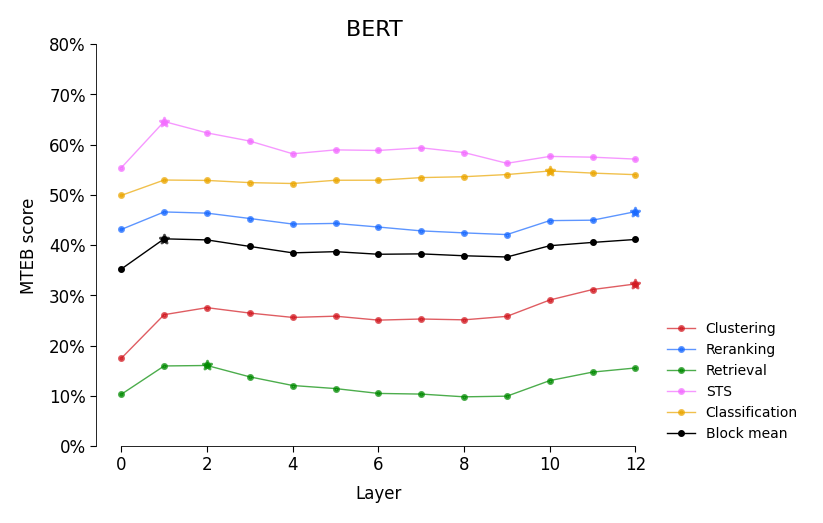

In [ ]:
%matplotlib inline


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")

# change with model:
model_name = "BERT"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_bert

# calculate block means
df_block_mean = pd.DataFrame()
df_block_mean["clustering"] = df_model[
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ]
].mean(axis=1)

df_block_mean["reranking"] = df_model[
    ["SciDocsRR", "MindSmallReranking"]
].mean(axis=1)
df_block_mean["retrieval"] = df_model[["SCIDOCS", "ArguAna"]].mean(axis=1)
df_block_mean["sts"] = df_model[["STS15", "STS16", "STSBenchmark"]].mean(
    axis=1
)
df_block_mean["classification"] = df_model[
    [
        "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ]
].mean(axis=1)

# create palette
palette = glasbey.create_palette(
    palette_size=len(df_block_mean.columns) + 1,
    lightness_bounds=(20, 75),
    chroma_bounds=(50, 90),
)


for i, elem in enumerate(df_block_mean.columns):
    if elem == "classification":
        i = i + 1
    ax.plot(
        df_block_mean.index,
        df_block_mean[elem],
        label=[elem.upper() if elem == "sts" else elem.capitalize()],
        c=palette[i],
        alpha=0.7,
        marker=".",
        ms=3,
    )
    ax.scatter(
        df_block_mean.index[np.argmax(df_block_mean[elem])],
        np.amax(df_block_mean[elem]),
        c=palette[i],
        alpha=0.7,
        marker="*",
        s=10,
    )


ax.plot(
    df_block_mean.index,
    df_block_mean.mean(axis=1),
    label="Block mean",
    c="k",
    # lw=1,
    marker=".",
    ms=3,
)
ax.scatter(
    df_block_mean.index[np.argmax(df_block_mean.mean(axis=1))],
    np.amax(df_block_mean.mean(axis=1)),
    c="k",
    alpha=0.7,
    marker="*",
    s=10,
)

ax.set_title(f"{model_name} {finetune_type}")
ax.legend(loc=(1, 0))
ax.set_ylim(0, 0.8)
ax.set_xticks(np.arange(7) * 2)
ax.set_xlabel("Layer")
ax.set_ylabel("MTEB score")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.spines.bottom.set_bounds(0, 12)

fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}_v2.png")
# fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}.pdf")

BERT:
Mid-layers: STS, classification (small difference), Retrieval (small difference), mean (small difference)
Last layers: Clustering, Reranking

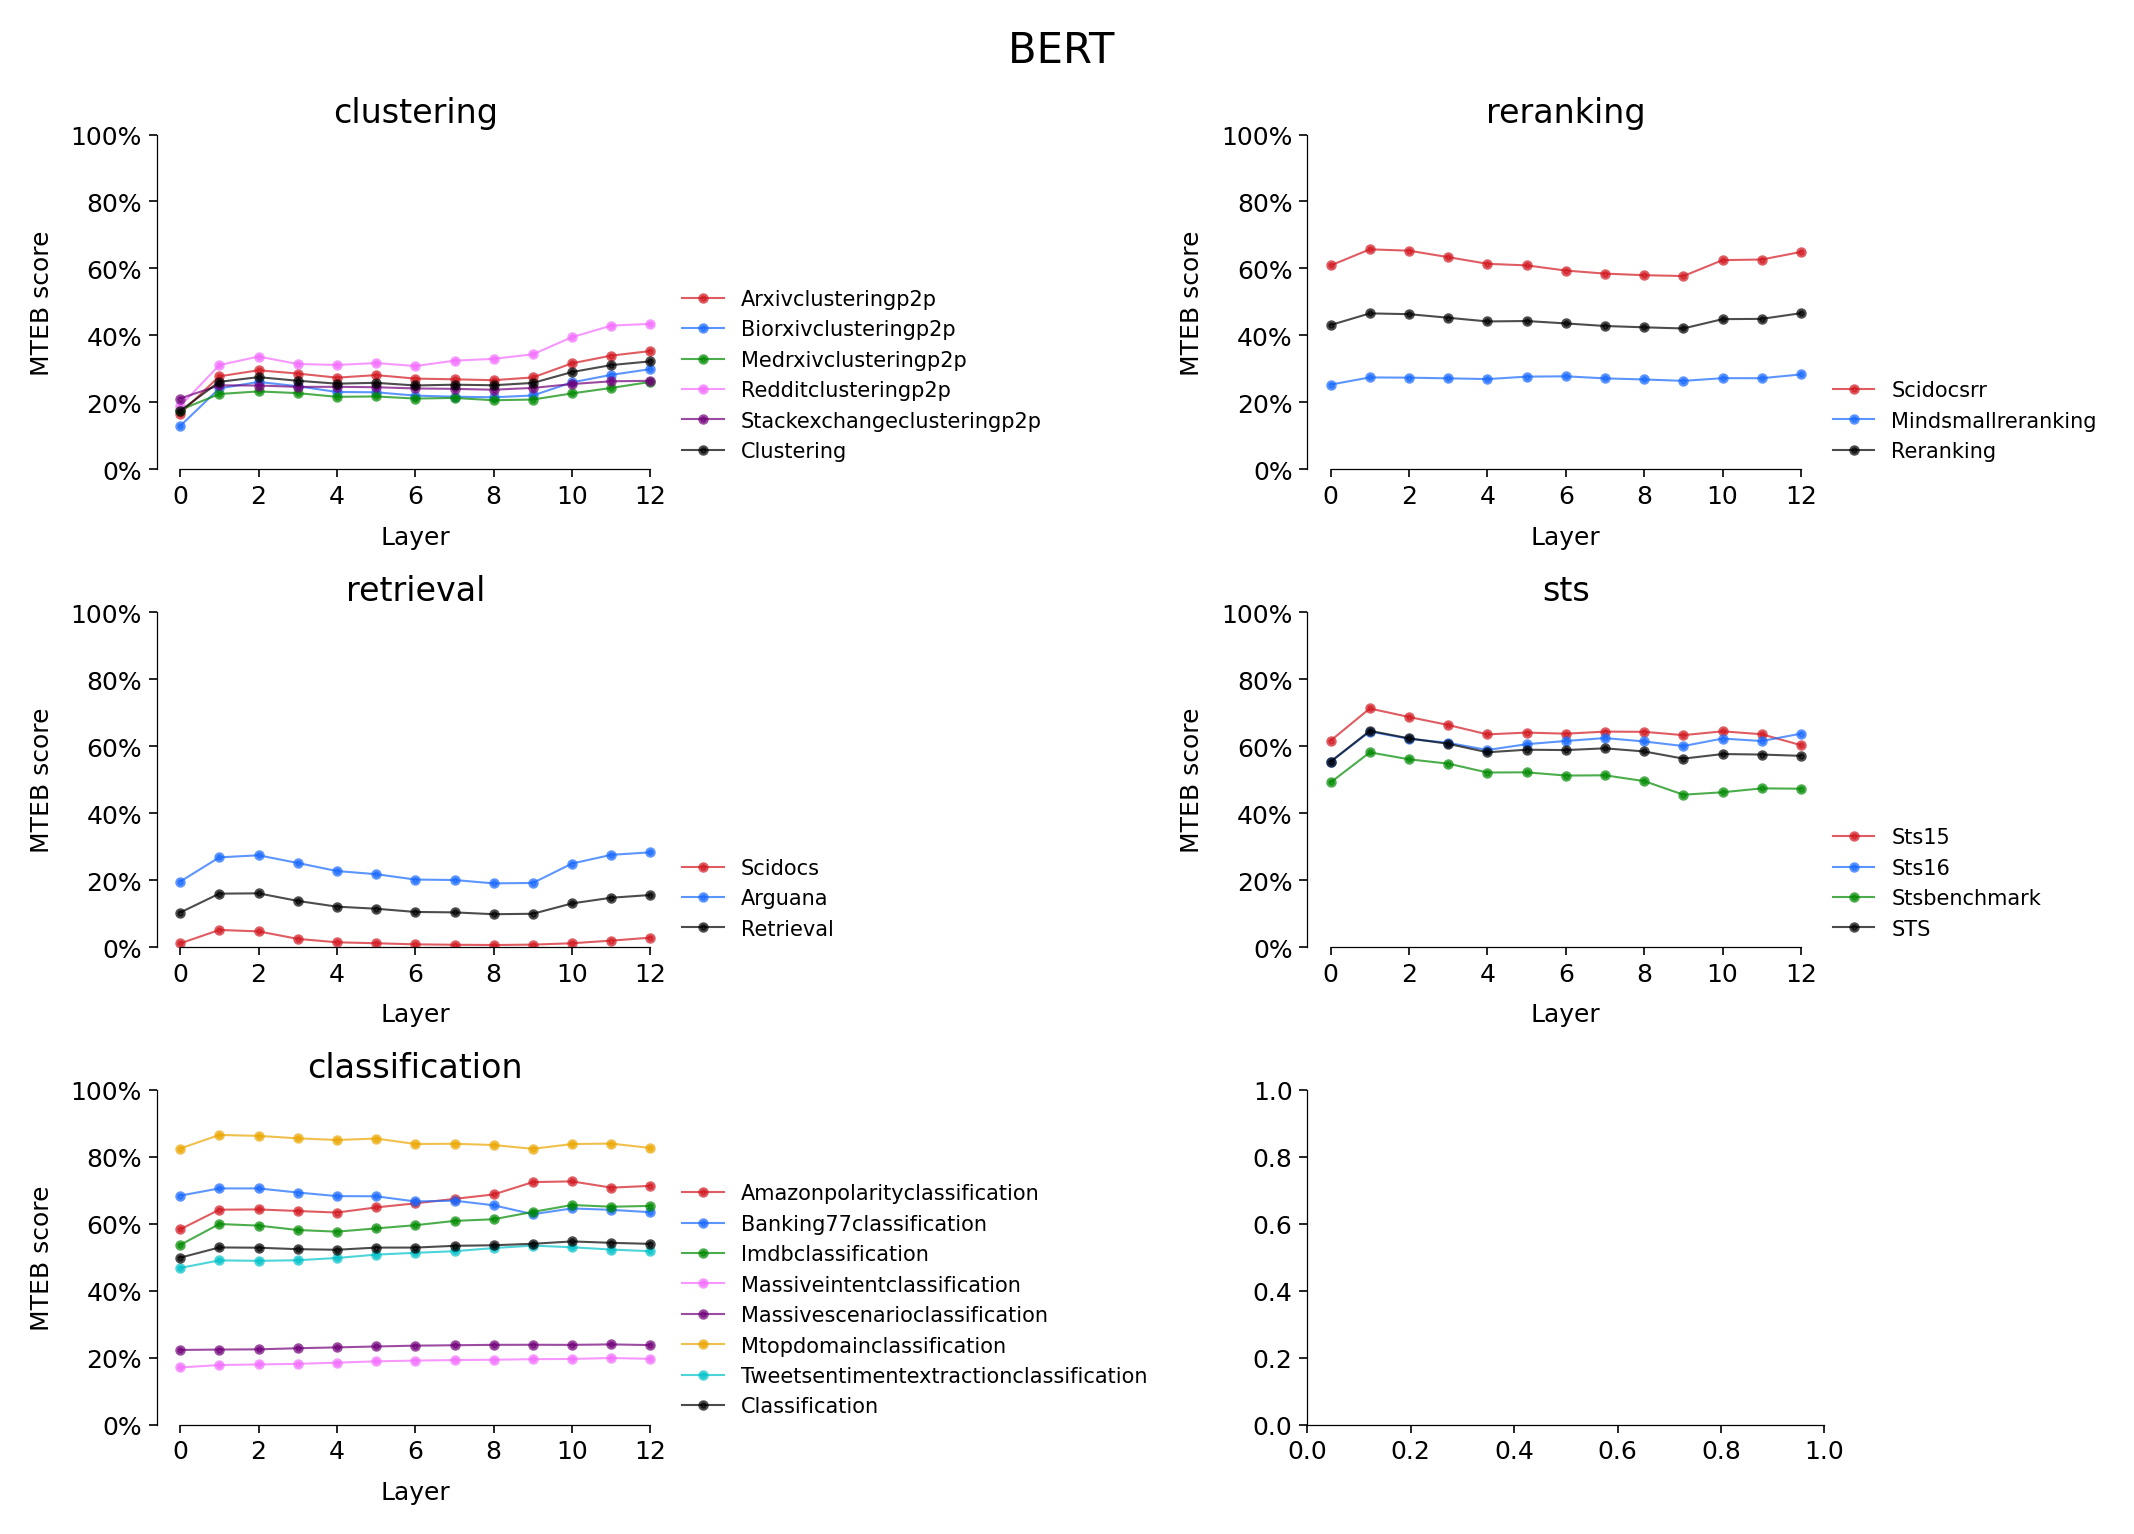

In [ ]:
%matplotlib inline


fig, axes = plt.subplots(3, 2, figsize=(7, 5), dpi=300, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")
axs = axes.flatten()

# change with model:
model_name = "BERT"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_bert

modalities_names = [
    "clustering",
    "reranking",
    "retrieval",
    "sts",
    "classification",
]
modalities = [
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ],
    ["SciDocsRR", "MindSmallReranking"],
    ["SCIDOCS", "ArguAna"],
    ["STS15", "STS16", "STSBenchmark"],
    [
        "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ],
]

df_block_mean = pd.DataFrame()

for j, mod in enumerate(modalities_names):
    tasks = modalities[j]
    df_modality = df_model[tasks]

    palette = glasbey.create_palette(
        palette_size=len(df_modality.columns) + 1,
        lightness_bounds=(20, 75),
        chroma_bounds=(50, 90),
    )

    for i, elem in enumerate(df_modality.columns):
        axs[j].plot(
            df_modality.index,
            df_modality[elem],
            label=[elem.capitalize()],
            c=palette[i],
            alpha=0.7,
            marker=".",
            ms=3,
        )

    df_block_mean[mod] = df_modality.mean(axis=1)

    axs[j].plot(
        df_block_mean.index,
        df_block_mean[mod],
        label=[mod.upper() if mod == "sts" else mod.capitalize()],
        c="k",
        alpha=0.7,
        marker=".",
        ms=3,
    )

    axs[j].set_title(f"{mod}")
    axs[j].legend(loc=(1, 0))
    axs[j].set_ylim(0, 1)
    axs[j].set_xticks(np.arange(7) * 2)
    axs[j].set_xlabel("Layer")
    axs[j].set_ylabel("MTEB score")
    axs[j].yaxis.set_major_formatter(
        ticker.PercentFormatter(xmax=1, decimals=0)
    )
    axs[j].spines.bottom.set_bounds(0, 12)

fig.suptitle(f"{model_name} {finetune_type}", fontsize=10)

fig.savefig(figures_path / f"mteb_modalities_layers_{saving_dir_str}.png")
# fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}.pdf")

## Pre-trained SBERT

In [ ]:
# IMPORT RESULTS
model_name = "SBERT"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}"
)

mteb_scores_layers_model = pd.DataFrame()

for layer_number in np.arange(13):
    # layer_number = 12
    saving_path = (
        Path("embeddings_" + model_name.lower())
        / Path("updated_dataset")
        / Path("mteb_benchmark")
        / Path("eval_layers")
        / Path(saving_dir_str)
        / Path(f"layer_{layer_number}")
    )
    root_directory = variables_path / saving_path
    mteb_results_model = load_mteb_results(root_directory)

    # unpack
    mteb_scores_model = create_results_dict(mteb_results_model)

    mteb_scores_layers_model[layer_number] = mteb_scores_model

mteb_scores_layers_sbert = mteb_scores_layers_model.T

In [ ]:
mteb_scores_layers_sbert

,AmazonPolarityClassification,ArguAna,ArxivClusteringP2P,Banking77Classification,BiorxivClusteringP2P,ImdbClassification,MTOPDomainClassification,MassiveIntentClassification,MassiveScenarioClassification,MedrxivClusteringP2P,MindSmallReranking,RedditClusteringP2P,SCIDOCS,STS15,STS16,STSBenchmark,SciDocsRR,StackExchangeClusteringP2P,TweetSentimentExtractionClassification
0,0.632269,0.31381,0.274047,0.709643,0.249939,0.559540,0.867601,0.138265,0.203295,0.223053,0.276066,0.292358,0.08922,0.756095,0.707504,0.663783,0.699404,0.244795,0.503848
1,0.648537,0.31114,0.324842,0.709545,0.280167,0.578504,0.874213,0.150303,0.211836,0.244798,0.290719,0.373559,0.07788,0.740000,0.713986,0.651474,0.723383,0.261371,0.517119
2,0.656216,0.28411,0.336957,0.705487,0.297314,0.599832,0.883037,0.151345,0.212475,0.256388,0.296210,0.408128,0.04698,0.695519,0.700926,0.598373,0.726096,0.263846,0.532484
3,0.686310,0.28001,0.347738,0.721006,0.298504,0.629292,0.885591,0.156153,0.215266,0.260345,0.296398,0.440955,0.03879,0.684418,0.695933,0.583546,0.727066,0.270608,0.547991
4,0.711904,0.27312,0.348020,0.736786,0.285587,0.649184,0.889535,0.158305,0.217048,0.257235,0.291842,0.440418,0.03759,0.686861,0.708582,0.614440,0.729399,0.271466,0.566469
5,0.723233,0.26142,0.345559,0.744058,0.280778,0.657552,0.891792,0.151883,0.209449,0.253287,0.289041,0.428562,0.03456,0.669361,0.715207,0.613209,0.729849,0.270422,0.574165
6,0.797800,0.22178,0.341775,0.746201,0.262783,0.703760,0.892841,0.155817,0.210625,0.246425,0.287682,0.433861,0.02861,0.667736,0.716961,0.612126,0.724398,0.263823,0.583899
7,0.832220,0.12302,0.336362,0.740292,0.261611,0.735836,0.882718,0.152051,0.203867,0.246795,0.283433,0.403504,0.02758,0.672311,0.704171,0.613268,0.713204,0.263610,0.590153
8,0.841714,0.12075,0.372952,0.760357,0.289798,0.760640,0.889033,0.149866,0.200202,0.268407,0.284855,0.450283,0.04464,0.715665,0.710059,0.648146,0.741714,0.281163,0.580079
9,0.777626,0.15855,0.400771,0.773701,0.311875,0.755504,0.904970,0.144015,0.190787,0.285974,0.288364,0.466657,0.05306,0.727685,0.706136,0.647548,0.770457,0.298819,0.564233


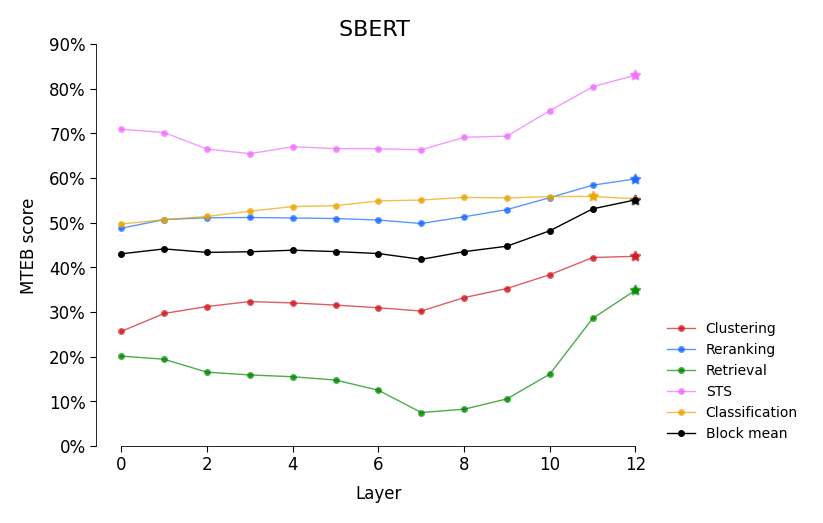

In [ ]:
%matplotlib inline


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")

# change with model:
model_name = "SBERT"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_sbert

# calculate block means
df_block_mean = pd.DataFrame()
df_block_mean["clustering"] = df_model[
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ]
].mean(axis=1)

df_block_mean["reranking"] = df_model[
    ["SciDocsRR", "MindSmallReranking"]
].mean(axis=1)
df_block_mean["retrieval"] = df_model[["SCIDOCS", "ArguAna"]].mean(axis=1)
df_block_mean["sts"] = df_model[["STS15", "STS16", "STSBenchmark"]].mean(
    axis=1
)
df_block_mean["classification"] = df_model[
    [
        # "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ]
].mean(axis=1)

# create palette
palette = glasbey.create_palette(
    palette_size=len(df_block_mean.columns) + 1,
    lightness_bounds=(20, 75),
    chroma_bounds=(50, 90),
)


for i, elem in enumerate(df_block_mean.columns):
    if elem == "classification":
        i = i + 1
    ax.plot(
        df_block_mean.index,
        df_block_mean[elem],
        label=[elem.upper() if elem == "sts" else elem.capitalize()],
        c=palette[i],
        alpha=0.7,
        marker=".",
        ms=3,
    )
    ax.scatter(
        df_block_mean.index[np.argmax(df_block_mean[elem])],
        np.amax(df_block_mean[elem]),
        c=palette[i],
        alpha=0.7,
        marker="*",
        s=10,
    )


ax.plot(
    df_block_mean.index,
    df_block_mean.mean(axis=1),
    label="Block mean",
    c="k",
    # lw=1,
    marker=".",
    ms=3,
)
ax.scatter(
    df_block_mean.index[np.argmax(df_block_mean.mean(axis=1))],
    np.amax(df_block_mean.mean(axis=1)),
    c="k",
    alpha=0.7,
    marker="*",
    s=10,
)

ax.set_title(f"{model_name} {finetune_type}")
ax.legend(loc=(1, 0))
ax.set_ylim(0, 0.9)
ax.set_xticks(np.arange(7) * 2)
ax.set_xlabel("Layer")
ax.set_ylabel("MTEB score")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.spines.bottom.set_bounds(0, 12)

fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}_v2.png")
# fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}.pdf")

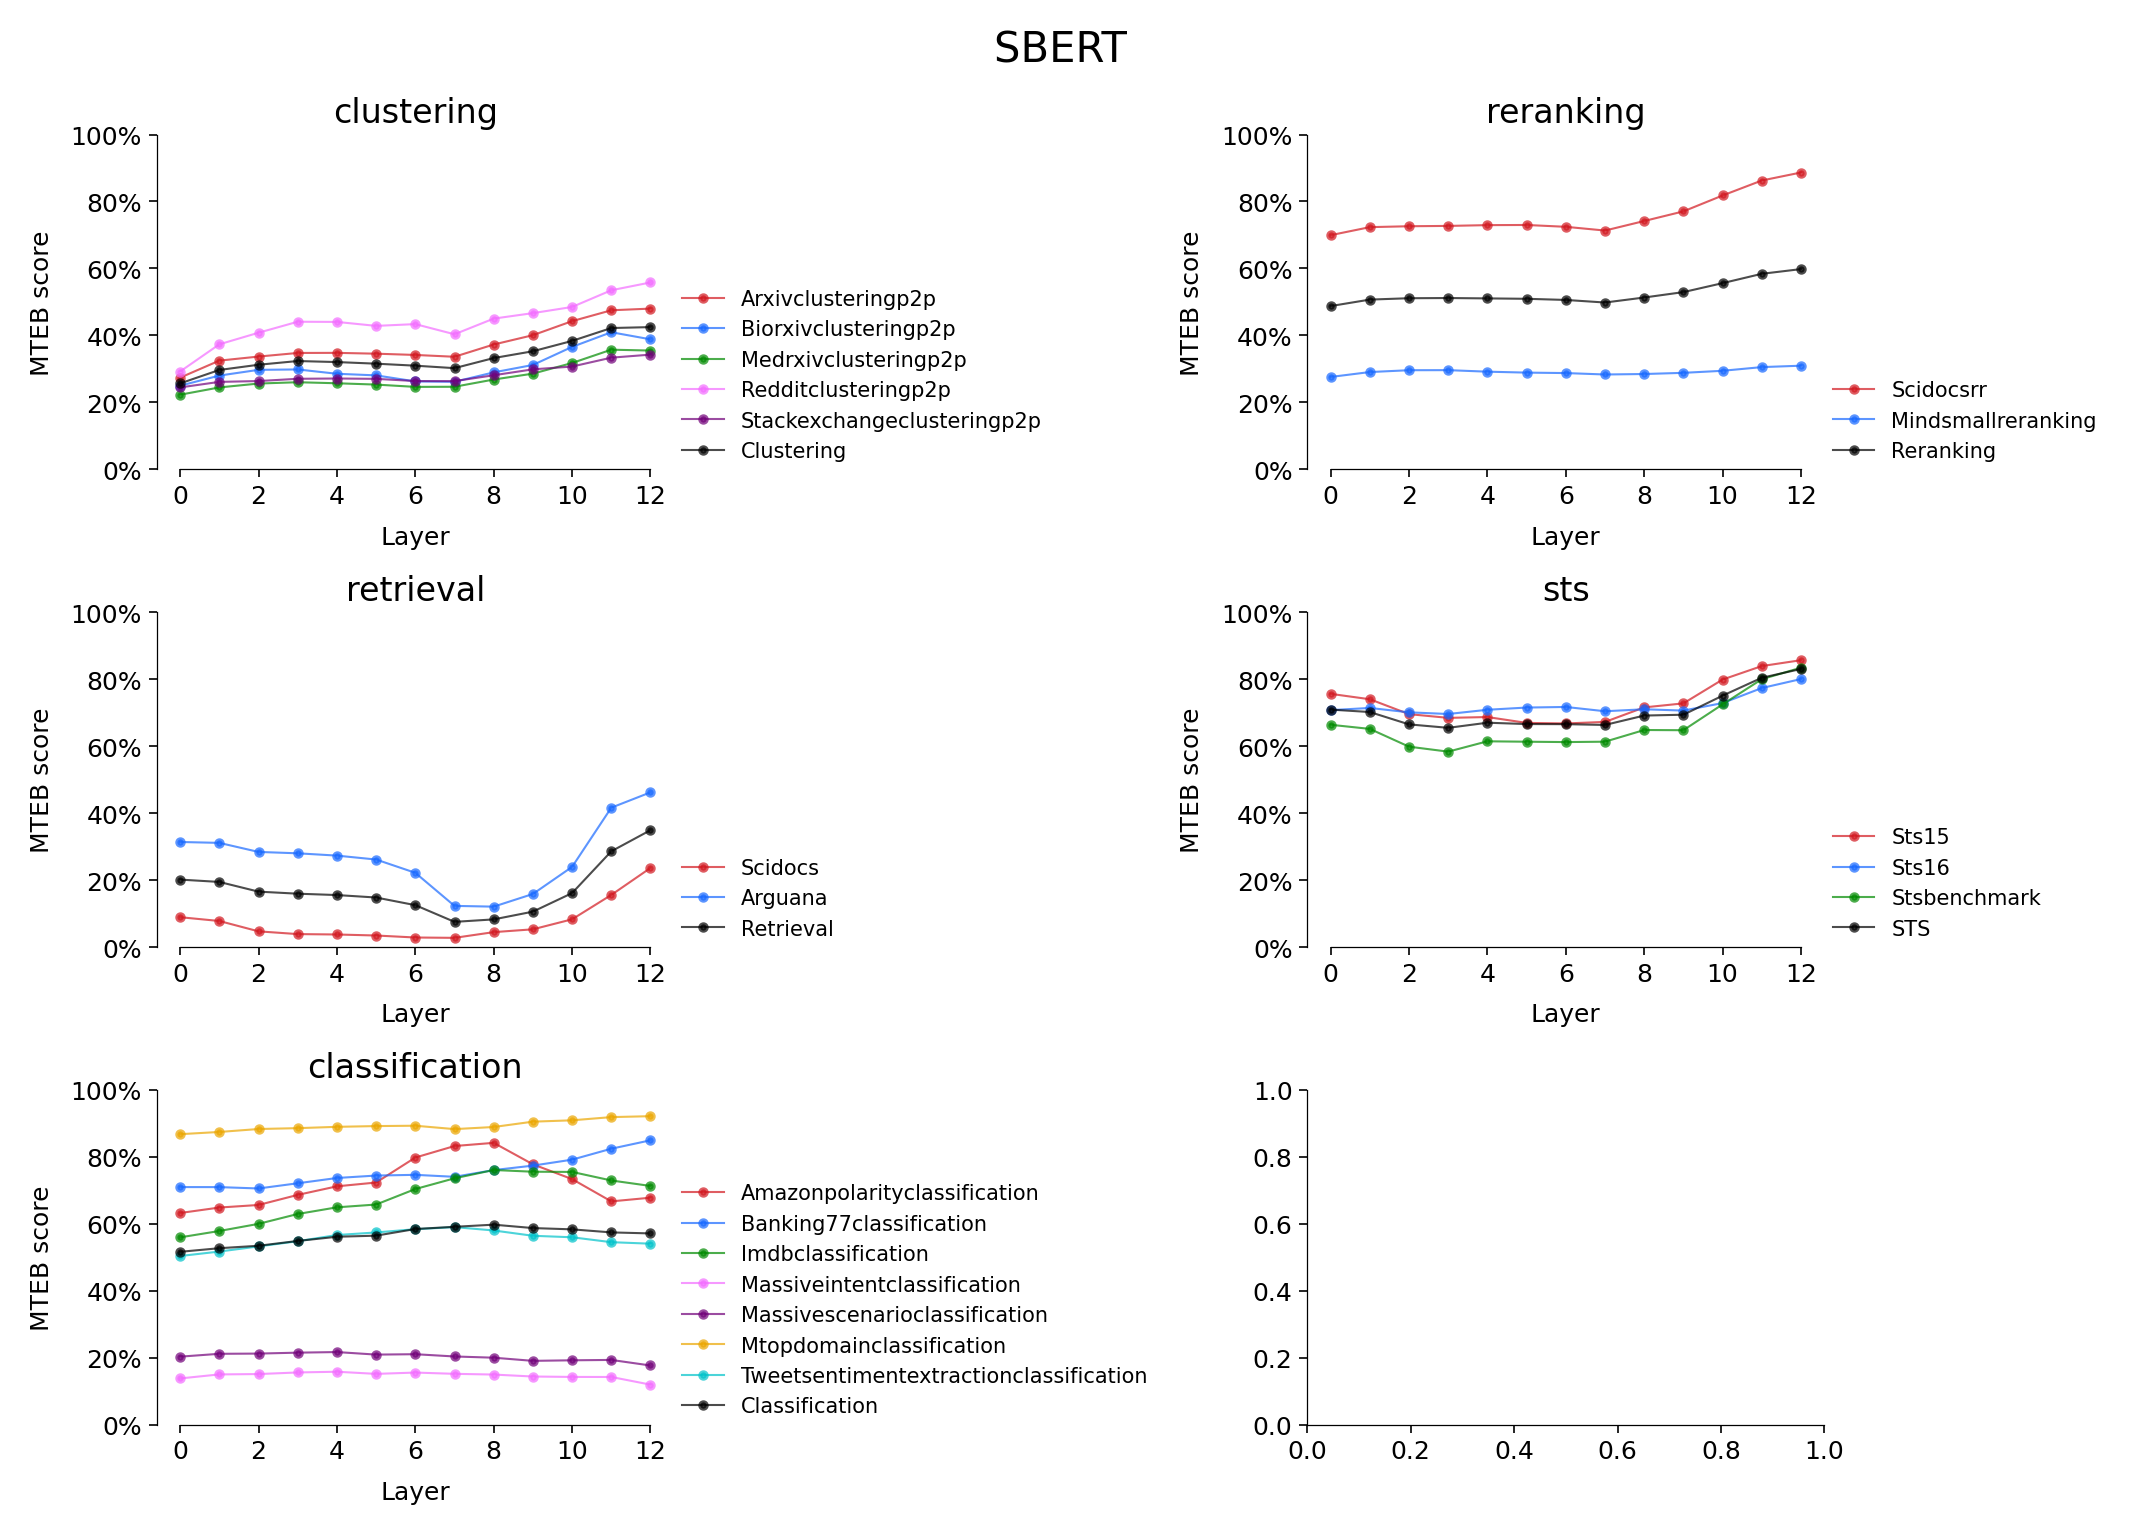

In [ ]:
%matplotlib inline


fig, axes = plt.subplots(3, 2, figsize=(7, 5), dpi=300, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")
axs = axes.flatten()

# change with model:
model_name = "SBERT"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
df_model = mteb_scores_layers_sbert

modalities_names = [
    "clustering",
    "reranking",
    "retrieval",
    "sts",
    "classification",
]
modalities = [
    [
        "ArxivClusteringP2P",
        "BiorxivClusteringP2P",
        "MedrxivClusteringP2P",
        "RedditClusteringP2P",
        "StackExchangeClusteringP2P",
    ],
    ["SciDocsRR", "MindSmallReranking"],
    ["SCIDOCS", "ArguAna"],
    ["STS15", "STS16", "STSBenchmark"],
    [
        "AmazonPolarityClassification",
        "Banking77Classification",
        "ImdbClassification",
        "MassiveIntentClassification",
        "MassiveScenarioClassification",
        "MTOPDomainClassification",
        "TweetSentimentExtractionClassification",
    ],
]

df_block_mean = pd.DataFrame()

for j, mod in enumerate(modalities_names):
    tasks = modalities[j]
    df_modality = df_model[tasks]

    palette = glasbey.create_palette(
        palette_size=len(df_modality.columns) + 1,
        lightness_bounds=(20, 75),
        chroma_bounds=(50, 90),
    )

    for i, elem in enumerate(df_modality.columns):
        axs[j].plot(
            df_modality.index,
            df_modality[elem],
            label=[elem.capitalize()],
            c=palette[i],
            alpha=0.7,
            marker=".",
            ms=3,
        )

    df_block_mean[mod] = df_modality.mean(axis=1)

    axs[j].plot(
        df_block_mean.index,
        df_block_mean[mod],
        label=[mod.upper() if mod == "sts" else mod.capitalize()],
        c="k",
        alpha=0.7,
        marker=".",
        ms=3,
    )

    axs[j].set_title(f"{mod}")
    axs[j].legend(loc=(1, 0))
    axs[j].set_ylim(0, 1)
    axs[j].set_xticks(np.arange(7) * 2)
    axs[j].set_xlabel("Layer")
    axs[j].set_ylabel("MTEB score")
    axs[j].yaxis.set_major_formatter(
        ticker.PercentFormatter(xmax=1, decimals=0)
    )
    axs[j].spines.bottom.set_bounds(0, 12)

fig.suptitle(f"{model_name} {finetune_type}", fontsize=10)

fig.savefig(figures_path / f"mteb_modalities_layers_{saving_dir_str}.png")
# fig.savefig(figures_path / f"mteb_layers_{saving_dir_str}.pdf")

## Combined plot

In [ ]:
# tab10 colors
tab10_colors = {
    "tab:blue": "#1f77b4",
    "tab:orange": "#ff7f0e",
    "tab:green": "#2ca02c",
    "tab:red": "#d62728",
    "tab:purple": "#9467bd",
    "tab:brown": "#8c564b",
    "tab:pink": "#e377c2",
    "tab:gray": "#7f7f7f",
    "tab:olive": "#bcbd22",
    "tab:cyan": "#17becf",
}

tab10_colors_light = {
    "tab:blue": "#7fbee9",
    "tab:orange": "#ffbf86",
    "tab:green": "#87de87",
    "tab:red": "#eb9293",
    "tab:purple": "#c9b3de",
    "tab:brown": "#cca69f",
    "tab:pink": "#f1bbe0",
    "tab:gray": "#bfbfbf",
    "tab:olive": "#e8e985",
    "tab:cyan": "#81e7f1",
}

In [ ]:
dict_color_models = {
    "MPNet": tab10_colors_light["tab:orange"],
    "MPNet (Dropout)": tab10_colors["tab:pink"],
    "MPNet (Crops)": tab10_colors["tab:orange"],
    "SBERT": tab10_colors["tab:green"],
    "BERT": tab10_colors_light["tab:blue"],
}

MPNet
clustering        0.274340
reranking         0.417625
retrieval         0.118100
sts               0.520212
classification    0.518488
Name: 12, dtype: float64
0.36975317582599454
classification
AmazonPolarityClassification              0.664892
Banking77Classification                   0.574091
ImdbClassification                        0.618060
MassiveIntentClassification               0.232448
MassiveScenarioClassification             0.252589
MTOPDomainClassification                  0.759439
TweetSentimentExtractionClassification    0.527900
Name: 12, dtype: float64
ArxivClusteringP2P            0.277987
BiorxivClusteringP2P          0.231671
MedrxivClusteringP2P          0.224710
RedditClusteringP2P           0.373795
StackExchangeClusteringP2P    0.263539
Name: 12, dtype: float64
SciDocsRR             0.560579
MindSmallReranking    0.274671
Name: 12, dtype: float64
SCIDOCS    0.01393
ArguAna    0.22227
Name: 12, dtype: float64
STS15           0.534896
STS16           0.5058

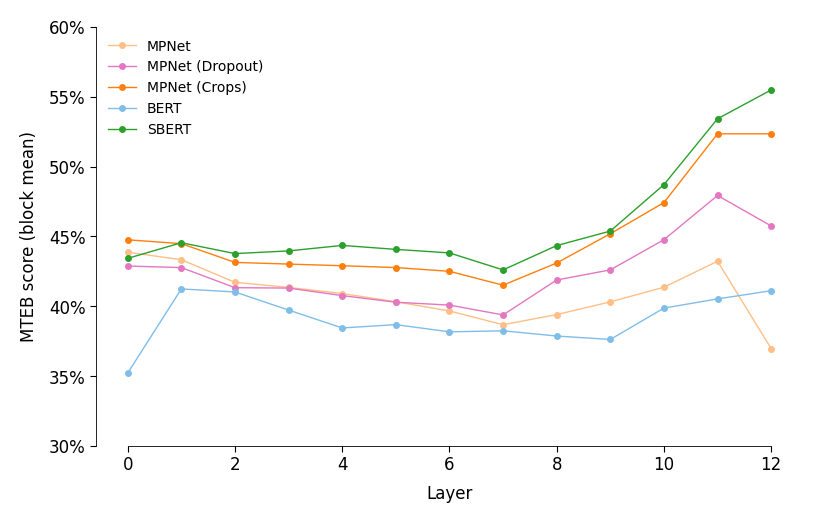

In [ ]:
%matplotlib inline


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200, layout="constrained")
# fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=200, layout="constrained")

# change with model:
model_name = "BERT"
finetune_type = ""
saving_dir_str = (
    f"results_{model_name.lower()}"
    if finetune_type == ""
    else f"results_{model_name.lower()}_{finetune_type}_finetuning"
)
# df_model = mteb_scores_layers_bert
df_models = [
    mteb_scores_layers_mpnet,
    mteb_scores_layers_mpnet_dropout,
    mteb_scores_layers_mpnet_crops,
    mteb_scores_layers_bert,
    mteb_scores_layers_sbert,
]
model_names = [
    "MPNet",
    "MPNet (Dropout)",
    "MPNet (Crops)",
    "BERT",
    "SBERT",
]

for model_name, df_model in zip(model_names, df_models):
    # calculate block means
    df_block_mean = pd.DataFrame()
    df_block_mean["clustering"] = df_model[
        [
            "ArxivClusteringP2P",
            "BiorxivClusteringP2P",
            "MedrxivClusteringP2P",
            "RedditClusteringP2P",
            "StackExchangeClusteringP2P",
        ]
    ].mean(axis=1)

    df_block_mean["reranking"] = df_model[
        ["SciDocsRR", "MindSmallReranking"]
    ].mean(axis=1)
    df_block_mean["retrieval"] = df_model[["SCIDOCS", "ArguAna"]].mean(axis=1)
    df_block_mean["sts"] = df_model[["STS15", "STS16", "STSBenchmark"]].mean(
        axis=1
    )
    df_block_mean["classification"] = df_model[
        [
            "AmazonPolarityClassification",
            "Banking77Classification",
            "ImdbClassification",
            "MassiveIntentClassification",
            "MassiveScenarioClassification",
            "MTOPDomainClassification",
            "TweetSentimentExtractionClassification",
        ]
    ].mean(axis=1)

    # # create palette
    # palette = glasbey.create_palette(
    #     palette_size=len(df_block_mean.columns) + 1,
    #     lightness_bounds=(20, 75),
    #     chroma_bounds=(50, 90),
    # )

    # for i, elem in enumerate(df_block_mean.columns):
    #     if elem == "classification":
    #         i = i + 1
    #     ax.plot(
    #         df_block_mean.index,
    #         df_block_mean[elem],
    #         label=[elem.upper() if elem == "sts" else elem.capitalize()],
    #         c=palette[i],
    #         alpha=0.7,
    #         marker=".",
    #         ms=3,
    #     )

    ax.plot(
        df_block_mean.index,
        df_block_mean.mean(axis=1),
        label=f"{model_name}",
        c=dict_color_models[model_name],
        # lw=1,
        marker=".",
        ms=3,
    )
    print(model_name)
    print(df_block_mean.loc[12])
    print(df_block_mean.mean(axis=1).loc[12])
    print("classification")
    print(
        df_model[
            [
                "AmazonPolarityClassification",
                "Banking77Classification",
                "ImdbClassification",
                "MassiveIntentClassification",
                "MassiveScenarioClassification",
                "MTOPDomainClassification",
                "TweetSentimentExtractionClassification",
            ]
        ].loc[12]
    )
    print(
        df_model[
            [
                "ArxivClusteringP2P",
                "BiorxivClusteringP2P",
                "MedrxivClusteringP2P",
                "RedditClusteringP2P",
                "StackExchangeClusteringP2P",
            ]
        ].loc[12]
    )
    print(df_model[["SciDocsRR", "MindSmallReranking"]].loc[12])
    print(df_model[["SCIDOCS", "ArguAna"]].loc[12])
    print(df_model[["STS15", "STS16", "STSBenchmark"]].loc[12])
    print("---------------")

ax.legend()  # loc=(1, 0))
ax.set_ylim(0.3, 0.60)  # (0, 0.8)
ax.set_xticks(np.arange(7) * 2)
ax.set_xlabel("Layer")
ax.set_ylabel("MTEB score (block mean)")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.spines.bottom.set_bounds(0, 12)

# fig.savefig(figures_path / f"mteb_layers_all_models_v4.png")